## Machine Learning


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valrqr/data-portfolio/blob/main/Data%20-%20Portfolio%20formation/Projet%20Fin%20de%20Formation/Projet_Diabete_machine_learning.ipynb)

### Imports

In [ ]:
import pandas as pd
import numpy as np

from random import uniform, randint

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, precision_recall_curve, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedGroupKFold

from xgboost import XGBClassifier

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import joblib

### Chargement des données

In [ ]:
# Lecture des données
df = pd.read_csv(
    "/content/diabetes.csv",
    keep_default_na = False) # On ne veut pas interpréter les valeurs NULL comme NA

### Pré-traitement


In [ ]:
def pre_traitement(df):
    # Filtre
    df = df[~df["categorie_sortie"].isin(["Expired/Deceased", "Hospice"])]
    # Limitation des valeurs extrêmes
    max_test_lab = 100
    max_medicament = 50
    max_score_visite = 10
    df["score_visite"] = (df["n_visite_externe"] > 0).astype(int) + (df["n_visite_urgence"] > 0).astype(int) + df["n_visite_hopital"]
    df["score_visite"] = np.where(df["score_visite"] > max_score_visite, max_score_visite, df["score_visite"])
    df["n_test_lab"] = np.where(df["n_test_lab"] > max_test_lab, max_test_lab, df["n_test_lab"])
    df["n_medicament"] = np.where(df["n_medicament"] > max_medicament, max_medicament, df["n_medicament"])
    df["n_diag_max_9"] = np.where(df["n_diag"] > 9, 9, df["n_diag"])
    # Renommage des colonnes
    df = df.rename(columns={
        "categorie_1": "categorie_diag_1",
        "categorie_2": "categorie_diag_2",
        "categorie_3": "categorie_diag_3"
    })
    return df

In [ ]:
df = pre_traitement(df)

/tmp/ipykernel_1388/262524740.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["score_visite"] = (df["n_visite_externe"] > 0).astype(int) + (df["n_visite_urgence"] > 0).astype(int) + df["n_visite_hopital"]
/tmp/ipykernel_1388/262524740.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["score_visite"] = np.where(df["score_visite"] > max_score_visite, max_score_visite, df["score_visite"])
/tmp/ipykernel_1388/262524740.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [ ]:
patients_ids = df["patient_id"] # Pour la stratification par groupe et éviter le même patient_id dans le train et le test

### Sélection des features

En ce basant sur les observations de l'exploration, nous allons sélectionner les features suivants :

In [ ]:
col_target = "readmis"
cols_num = [
    'duree',
    'n_test_lab', 'n_procedure', 'n_medicament',
    'score_visite', 'n_diag_max_9',
    'n_changement_posologie'
]
cols_cat = [
    'tranche_age',
    'insulin',
    'ethnie', 'genre',
    'categorie_sortie',
    'categorie_source_admission',
    'categorie_specialite',
    'categorie_type_admission',
    'categorie_diag_1', 'categorie_diag_2', 'categorie_diag_3'
]
cols_feature = cols_num + cols_cat

In [ ]:
df = df[cols_feature+[col_target]]
df.head()

,duree,n_test_lab,n_procedure,n_medicament,score_visite,n_diag_max_9,n_changement_posologie,tranche_age,insulin,ethnie,genre,categorie_sortie,categorie_source_admission,categorie_specialite,categorie_type_admission,categorie_diag_1,categorie_diag_2,categorie_diag_3,readmis
0,1,1,2,1,0,9,0,[80-90),No,Caucasian,Male,Home,Outpatient,Urology,Elective,Cardiovascular,Respiratory,Genitourinary/Renal,0
1,1,1,1,1,0,4,0,[10-20),Steady,Caucasian,Male,Home,Emergency,?,Emergency,Injury/Trauma/Poisoning,Injury/Trauma/Poisoning,External Causes,0
2,1,1,0,1,0,1,0,[0-10),No,Caucasian,Male,Home,Outpatient,Pediatrics,Urgent,Endocrine/Metabolic/Nutritional,?,?,0
3,1,1,0,1,0,6,0,[60-70),No,Caucasian,Male,Home,Emergency,?,Emergency,Genitourinary/Renal,Genitourinary/Renal,Genitourinary/Renal,0
4,2,1,1,1,0,6,0,[40-50),No,Caucasian,Male,Home,Outpatient,?,Elective,Neoplasms/Cancer,Endocrine/Metabolic/Nutritional,Cardiovascular,0


### Encodage des features catégorielles

Deux types d'encodage seront utilisés :
- LabelEncoder : pour la tranche d'age car elle suit un ordre logique (de la plus petite à la plus grande tranche d'age)
- OneHotEncoder : pour le reste des features categorielles

In [ ]:
def encode(df):
    global cols_cat
    global cols_num
    # Encodage de tranche age
    encoder_age = LabelEncoder()
    encoder_age.fit(["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)", "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"])
    df["tranche_age_num"] = encoder_age.transform(df["tranche_age"])
    cols_num.append("tranche_age_num")
    # Encodage des variables catégorielles
    cols_cat = [e for e in cols_cat if e!="tranche_age"]
    encoder_onehot = OneHotEncoder(sparse_output=False)
    encoded_array = encoder_onehot.fit_transform(df[cols_cat])
    df = pd.concat([df.reset_index(drop=True), pd.DataFrame(encoded_array, columns=encoder_onehot.get_feature_names_out(cols_cat))], axis=1)
    return df.drop(columns=cols_cat+["tranche_age"])

In [ ]:
X = encode(df.copy())
X.head()

,duree,n_test_lab,n_procedure,n_medicament,score_visite,n_diag_max_9,n_changement_posologie,readmis,tranche_age_num,insulin_Down,...,categorie_diag_3_Injury/Trauma/Poisoning,categorie_diag_3_Mental/Psychiatric,categorie_diag_3_Musculoskeletal/Rheumatologic,categorie_diag_3_Neoplasms/Cancer,categorie_diag_3_Nervous System/Neurologic,categorie_diag_3_Obstetrics/Pregnancy,categorie_diag_3_Organ Replacement/Prosthetics,categorie_diag_3_Respiratory,categorie_diag_3_Skin/Soft Tissue,categorie_diag_3_Symptoms/Signs
0,1,1,2,1,0,9,0,0,8,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,1,1,0,4,0,0,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,0,1,0,1,0,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,0,1,0,6,0,0,6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,1,1,1,0,6,0,0,4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X.shape

(99343, 124)

### Scaling

In [ ]:
scaler = StandardScaler()
X[cols_num] = scaler.fit_transform(X[cols_num])


### Clustering


In [ ]:
inerties = []
silouhettes = []
X_subsample = X.sample(n=10000, random_state=37)[cols_num + [col_target]]
y_subsample = X_subsample.pop(col_target)
for k in range(2, 10):
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans_fit = kmeans.fit(X_subsample)
    inerties.append(kmeans_fit.inertia_)
    segments = kmeans_fit.predict(X_subsample)
    silouhettes.append(silhouette_score(X_subsample, segments))

2
3
4
5
6
7
8
9


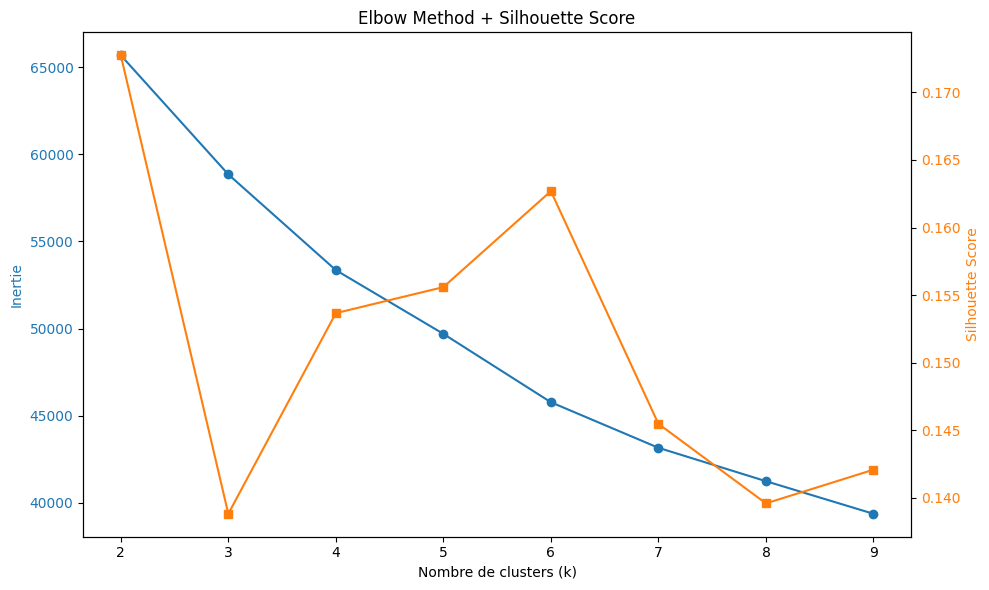

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: inertia
color1 = 'tab:blue'
ax1.set_xlabel("Nombre de clusters (k)")
ax1.set_ylabel("Inertie", color=color1)
ax1.plot(range(2, 10), inerties, marker="o", color=color1, label="Inertie")
ax1.tick_params(axis='y', labelcolor=color1)

# Secondary y-axis: silhouette score
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel("Silhouette Score", color=color2)
ax2.plot(range(2, 10), silouhettes, marker="s", color=color2, label="Silhouette")
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Elbow Method + Silhouette Score")
fig.tight_layout()
plt.show()

D'après le graph, nous sélectionnons 6 clusters.

In [ ]:
k = 6
X_kmeans = X_subsample.copy()
X_kmeans["Cluster"] = KMeans(n_clusters=k, random_state=42, n_init=5).fit_predict(X_subsample)
X_kmeans[col_target] = y_subsample

In [ ]:
pd.concat([X_kmeans.groupby("Cluster").mean(), X_kmeans.groupby("Cluster").size()], axis=1).rename({0: "n"}, axis=1).T

Cluster,0,1,2,3,4,5
duree,0.050986,-0.408802,-0.529972,-0.166063,1.600159,-0.037402
n_test_lab,0.079080,-0.437000,-0.381895,0.015349,0.847938,0.016877
n_procedure,-0.269333,1.652811,-0.373075,-0.478776,0.917175,-0.353171
n_medicament,0.165571,0.029924,-0.639266,-0.268906,1.533598,0.080520
score_visite,2.775769,-0.298035,-0.332849,-0.177398,-0.131797,-0.061724
n_diag_max_9,0.277560,0.050635,-1.333187,0.468978,0.479474,0.293067
n_changement_posologie,0.070424,-0.402238,-0.363294,-0.589040,0.241208,1.606033
tranche_age_num,-0.353494,-0.024537,-0.712202,0.461196,0.090218,0.078238
readmis,0.255390,0.087849,0.067548,0.108228,0.133964,0.125366
n,603.000000,1218.000000,2043.000000,3160.000000,1269.000000,1707.000000


Analyse des clusters :
- **0** : Patients ultra-vulnérables (6% des hospitalisations, 26% de réadmission) :
  - Score de visites très élevé (forte activité médicale antérieure),
  - jeunes,
  - peu de procédures
  - *Conclusion* : patients chroniques, connus du système de santé.
- **1 et 2** : Patients stables (36% des hospitalisations, ~8% de réadmission) :
  - Séjours courts,
  - peu de visites antérieures,
  - peu de tests/médicaments
  - *Conclusion* : patients avec diabète bien contrôlé, hospitalisés pour une raison mineure.
- **3, 4 et 5**: Patients hospitalisés complexes (58% des hospitalisations, ~12% de réadmission) :
  - Séjours plus longs,
  - plus de tests,
  - patients âgés
  - *Conclusion* : Hétérogènes en termes de trajectoire post-hospitalière.

Avec DBSCAN:

In [ ]:
bruits = []
clusters = []
for eps in np.arange(0.1, 3, 0.1):
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_subsample)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_bruit = list(labels).count(-1)
    clusters.append(n_clusters)
    bruits.append(n_bruit)
    print(f"eps={eps} : {n_clusters} clusters, {n_bruit} points classes bruit")

eps=0.1 : 0 clusters, 10000 points classes bruit
eps=0.2 : 0 clusters, 10000 points classes bruit
eps=0.30000000000000004 : 0 clusters, 10000 points classes bruit
eps=0.4 : 5 clusters, 9911 points classes bruit
eps=0.5 : 12 clusters, 9688 points classes bruit
eps=0.6 : 16 clusters, 9136 points classes bruit
eps=0.7000000000000001 : 14 clusters, 7860 points classes bruit
eps=0.8 : 12 clusters, 5855 points classes bruit
eps=0.9 : 7 clusters, 4285 points classes bruit
eps=1.0 : 4 clusters, 2933 points classes bruit
eps=1.1 : 3 clusters, 2037 points classes bruit
eps=1.2000000000000002 : 2 clusters, 1417 points classes bruit
eps=1.3000000000000003 : 3 clusters, 985 points classes bruit
eps=1.4000000000000001 : 4 clusters, 720 points classes bruit
eps=1.5000000000000002 : 3 clusters, 501 points classes bruit
eps=1.6 : 3 clusters, 313 points classes bruit
eps=1.7000000000000002 : 3 clusters, 233 points classes bruit
eps=1.8000000000000003 : 4 clusters, 166 points classes bruit
eps=1.90000000

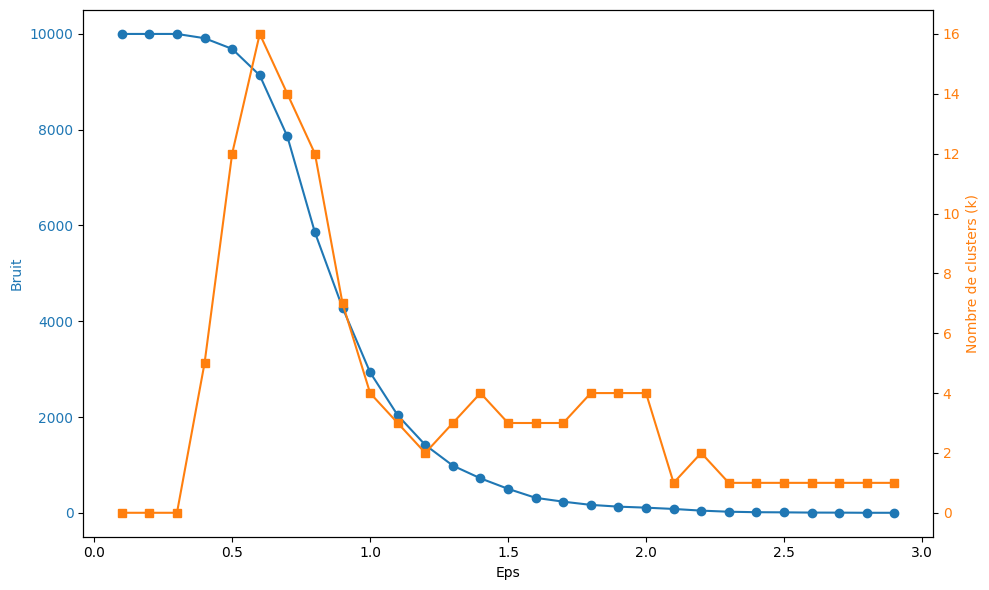

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: inertia
color1 = 'tab:blue'
ax1.set_xlabel("Eps")
ax1.set_ylabel("Bruit", color=color1)
ax1.plot(np.arange(0.1, 3, 0.1), bruits, marker="o", color=color1, label="Bruit")
ax1.tick_params(axis='y', labelcolor=color1)

# Secondary y-axis: silhouette score
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel("Nombre de clusters (k)", color=color2)
ax2.plot(np.arange(0.1, 3, 0.1), clusters, marker="s", color=color2, label="Clusters")
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()
plt.show()

Avec un minimum de 10 éléments par clusters, nous allons sélectionner une valeur d'eps de 2 pour obtenir 4 cluster et très peu de bruits (hospitalisation sans cluster)

In [ ]:
X_kmeans["Cluster_DBSCAN"] = DBSCAN(eps=2, min_samples=10).fit_predict(X_subsample)
pd.concat([X_kmeans.groupby("Cluster_DBSCAN").mean(), X_kmeans.groupby("Cluster_DBSCAN").size()], axis=1).rename({0: "n"}, axis=1).T

Cluster_DBSCAN,-1,0,1,2,3
duree,0.957720,-0.097731,0.183657,0.315078,0.246524
n_test_lab,0.275209,-0.067493,0.126109,0.252063,0.566258
n_procedure,0.760754,0.014777,-0.008767,-0.328261,-0.131036
n_medicament,1.194622,-0.122218,0.309753,0.321616,0.551570
score_visite,2.150725,-0.092424,0.075219,-0.126579,6.161136
n_diag_max_9,-0.042384,-0.045009,0.155028,0.301157,0.658397
n_changement_posologie,2.106035,-0.589040,1.460735,3.510510,1.460735
tranche_age_num,-0.969986,0.043619,-0.078492,0.122441,-1.719084
Cluster,2.416667,2.389464,4.075501,4.988764,0.000000
readmis,0.231481,0.104124,0.130161,0.101124,0.555556


Analyse des clusters
- **3** : 55% de réadmissions mais 9 éléments seulemnt
  - Sejour de longue durée
  - Nombreux tests en laboratoire
  - Beaucoup de médicaments donnés
  - Score visite extreme
  - Patients jeunes
- **-1** (le bruit) : hospitalisations avec un parcours atypique donne lieu à 2x plus de réadmission, 108 éléments
- **0 et 2** : 10% de réadmissions, 73% des hospitalisation
  - Observations semblable aux cluster KMEans 1 et 2
- **1** : 13% de réadmission, 25% des hospitalisations

### Prédiction

Nous allons maintenant tenter d'entrainer des modèles pour prédire la réadmission.

Le but sera de maximiser le recall (nous ne voulons pas manquer des réadmissions, nous tromper n'est pas très grave).

Nous sommes devant un problème de classification binaire, nous pouvons donc utiliser :
- **LogisticRegression**, un modèle linéaire simple
- **SGDClassifier**, un modèle linéaire utilisant la déscente de gradiant stochastique
- **RandomForestClassifier**, utilisant la méthode des ensemble avec des arbres de décision
- **XGBClassifier**, une autre méthode des ensemble avec des arbres de décision

Commencons par séparer nos données en training et test set.

Nous voulons éviter qu'un même patient se retrouve à la fois ans le training et les test set (fuite de données) et stratifier pour la réadmission.

In [ ]:
y = X.pop(col_target)
sgkf = StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)
train_idx, test_idx = next(sgkf.split(X, y, groups=patients_ids))

In [ ]:
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train class distribution: {y_train.value_counts(normalize=True)}")
print(f"Test class distribution: {y_test.value_counts(normalize=True)}")
print(f"Overall class distribution: {y.value_counts(normalize=True)}")

print(f"Train patients: {patients_ids.iloc[train_idx].nunique()}")
print(f"Test patients: {patients_ids.iloc[test_idx].nunique()}")
print(f"Overlap: {len(set(patients_ids.iloc[train_idx]) & set(patients_ids.iloc[test_idx]))}")

print(f"X_train: {X_train.shape}, nombre de réadmissions: {y_train.sum()} ({y_train.sum()/X_train.shape[0]*100:.2f}%)")
print(f"X_test: {X_test.shape}, nombre de réadmissions: {y_test.sum()} ({y_test.sum()/X_test.shape[0]*100:.2f}%)")

Train class distribution: readmis
0    0.885388
1    0.114612
Name: proportion, dtype: float64
Test class distribution: readmis
0    0.889035
1    0.110965
Name: proportion, dtype: float64
Overall class distribution: readmis
0    0.886112
1    0.113888
Name: proportion, dtype: float64
Train patients: 55952
Test patients: 14038
Overlap: 0
X_train: (79625, 123), nombre de réadmissions: 9126 (11.46%)
X_test: (19718, 123), nombre de réadmissions: 2188 (11.10%)


#### Entrainement de modèles

Cherchons une bonne combinaison d'hyperparametres pour nos modèles.


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'SGDClassifier': SGDClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42)
}

In [ ]:
param_distributions = {
    'LogisticRegression': [{
        'C': np.arange(0.1, 1, 0.3),
        'l1_ratio': np.arange(0, 1.1, 0.2),
        'solver': ['saga'],
        'max_iter': [100, 500, 1000]
    },
    {
        'C': np.arange(0.1, 1, 0.3),
        'solver': ['liblinear', 'newton-cholesky'],
        'max_iter': [100, 500, 1000]
    }],
    'SGDClassifier': [{
        'penalty': ['elasticnet'],
        'l1_ratio': np.arange(0, 1, 0.2),
        'loss': ['log_loss'],
        'max_iter': [100, 500, 1000]
    },
    {
        'alpha': np.arange(0, 0.01, 0.0001),
        'loss': ['hinge'],
        'max_iter': [100, 500, 1000]
    }],
    'RandomForestClassifier': [{
        'n_estimators': np.arange(50, 201, 50),
        'max_depth': [5, 10, 20, 30],
        'min_samples_split': np.arange(10, 100, 10),
        'min_samples_leaf': np.arange(5, 30, 5)
    }],
    'XGBClassifier': [{
        'n_estimators': np.arange(50, 201, 50),
        'max_depth': [5, 10, 20, 30],
        'learning_rate': np.arange(0.01, 0.3, 0.05),
        'subsample': np.arange(0.1, 0.8, 0.1)
    }]
}

In [ ]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
def find_best_hyperparameters(models, param_distributions, X, y):
  results = {}
  for name, model in models.items():
      print(name)
      max_score = -1
      i = 1
      for params in param_distributions[name]:
          print(f"Parametres : {i}")
          i += 1
          search = RandomizedSearchCV(
              model,
              params,
              n_iter=10,
              cv=5,   # D'après la doc de scikit-learn: For integer/None inputs, if the estimator is a classifier and y is either binary or multiclass, StratifiedKFold is used.
              scoring='roc_auc',
              n_jobs=-1,
              random_state=42
          )
          search.fit(X, y, sample_weight=weights)
          if search.best_score_ > max_score:
              max_score = search.best_score_
              results[name] = {
                  'best_params': search.best_params_,
                  'best_score': search.best_score_,
                  'best_model': search.best_estimator_
              }
      print(results[name])
  return results

In [ ]:
results = find_best_hyperparameters(models=models, param_distributions=param_distributions, X=X_train, y=y_train)

LogisticRegression
Parametres : 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Parametres : 2
{'best_params': {'solver': 'liblinear', 'max_iter': 100, 'C': np.float64(0.1)}, 'best_score': np.float64(0.6502787947588452), 'best_model': LogisticRegression(C=np.float64(0.1), random_state=42, solver='liblinear')}
SGDClassifier
Parametres : 1
Parametres : 2
{'best_params': {'max_iter': 500, 'loss': 'hinge', 'alpha': np.float64(0.006500000000000001)}, 'best_score': np.float64(0.6487867309892396), 'best_model': SGDClassifier(alpha=np.float64(0.006500000000000001), max_iter=500,
              random_state=42)}
RandomForestClassifier
Parametres : 1
{'best_params': {'n_estimators': np.int64(150), 'min_samples_split': np.int64(50), 'min_samples_leaf': np.int64(10), 'max_depth': 5}, 'best_score': np.float64(0.6427914834849053), 'best_model': RandomForestClassifier(max_depth=5, min_samples_leaf=np.int64(10),
                       min_samples_split=np.int64(50),
                       n_estimators=np.int64(150), random_state=42)}
XGBClassifier
Parametres : 1
{'best_params': {'

Résultat de la recherche d'hyperparamètres et d'évaluation des modèles (roc_auc) :
- **LogisticRegression**: 0.65
- **SGDClassifier**: 0.65
- **RandomForestClassifier**: 0.64
- **XGBoost**: 0.56

Tous les modèles sont moyens, XGBoost un peu moins performant.

Essayons d'identifier les features avec une faible contribution pour les retirer:

In [ ]:
# results = {
#     "LogisticRegression": {
#         'best_model': joblib.load("LogisticRegression_full.joblib")
#     },
#     "SGDClassifier": {
#         'best_model': joblib.load("SGDClassifier_full.joblib")
#     },
#     "RandomForestClassifier": {
#         'best_model': joblib.load("RandomForestClassifier_full.joblib")
#     },
#     "XGBClassifier": {
#         'best_model': joblib.load("XGBClassifier_full.joblib")
#     }
# }


LogisticRegression:


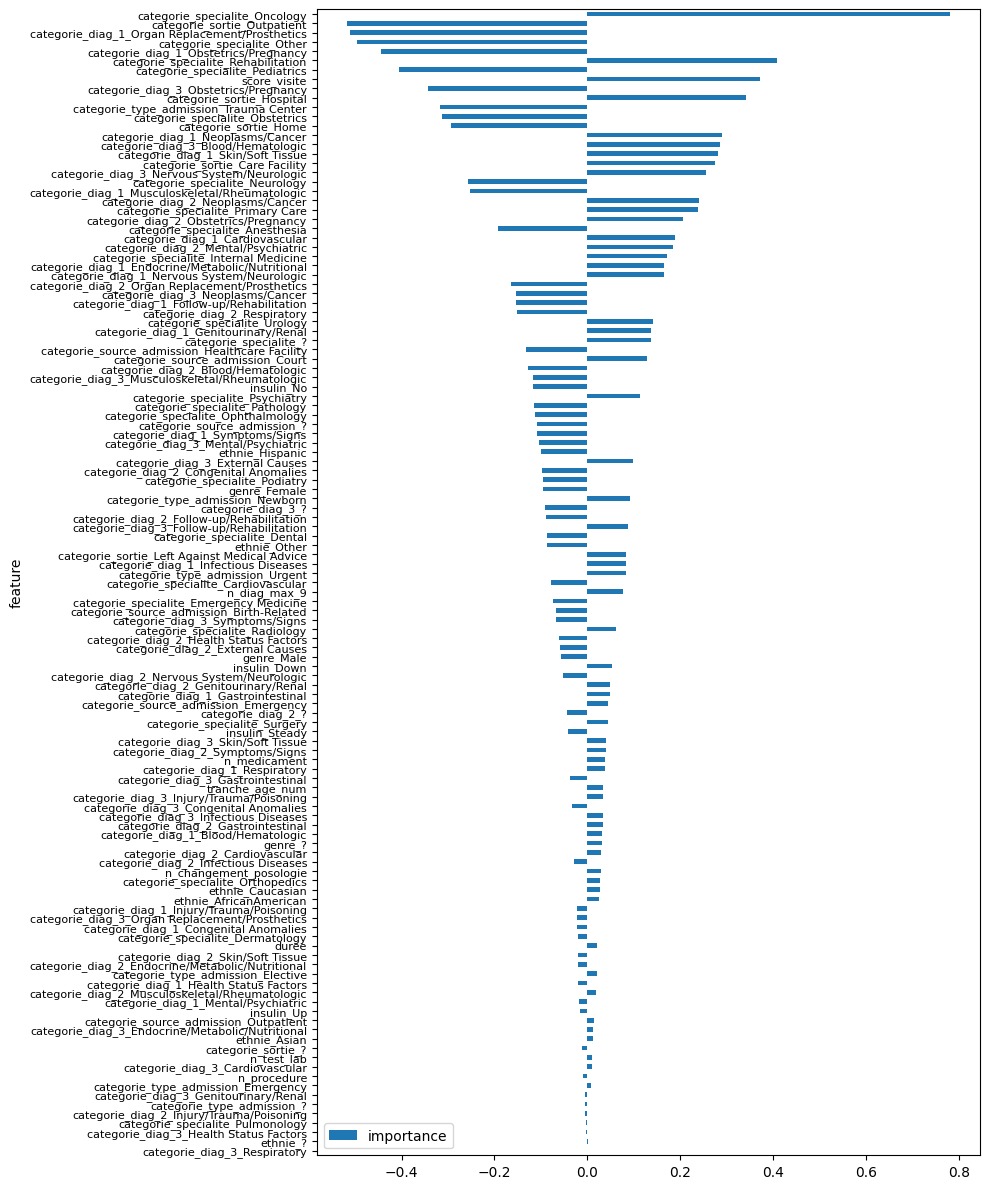


SGDClassifier:


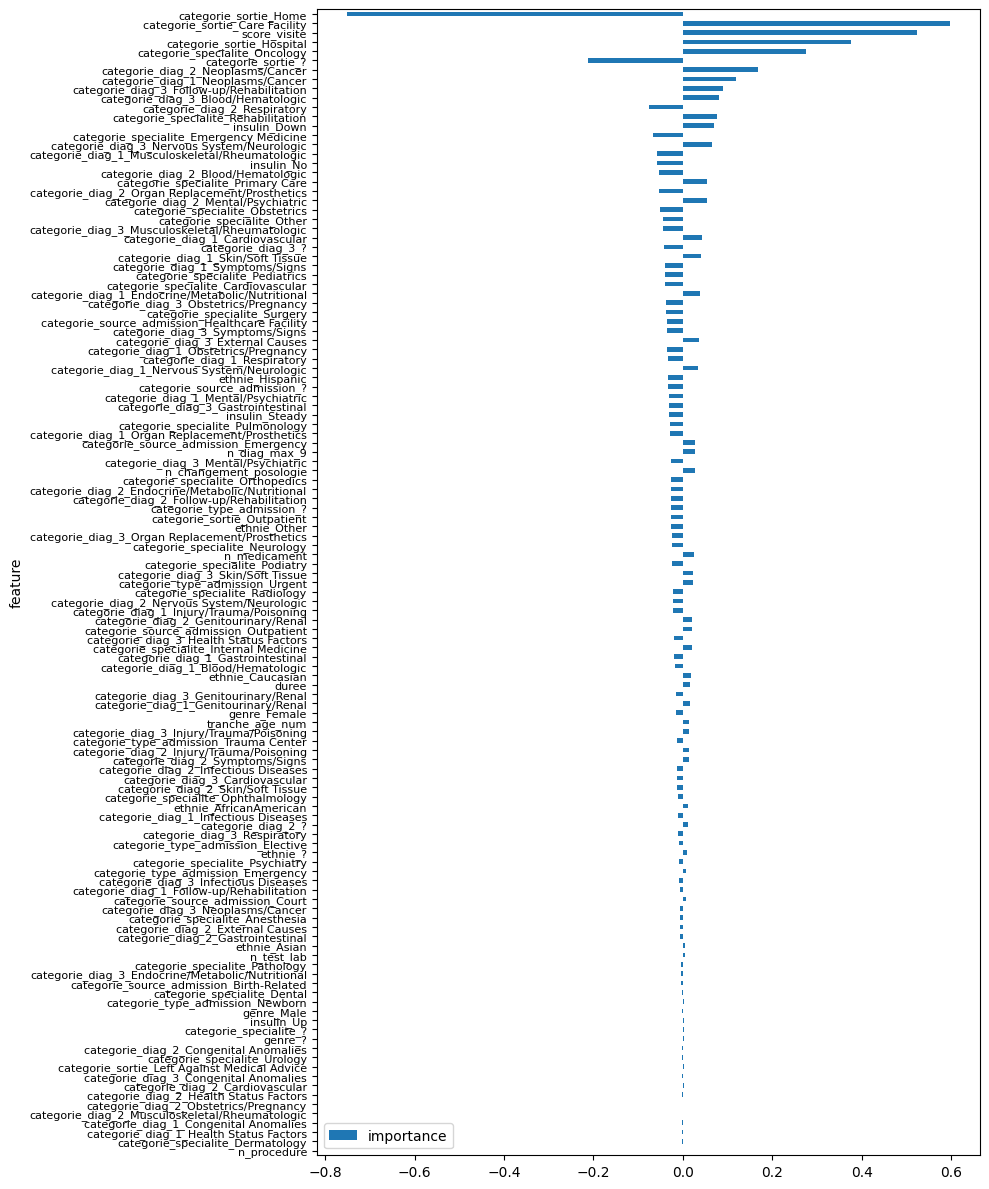


RandomForestClassifier:


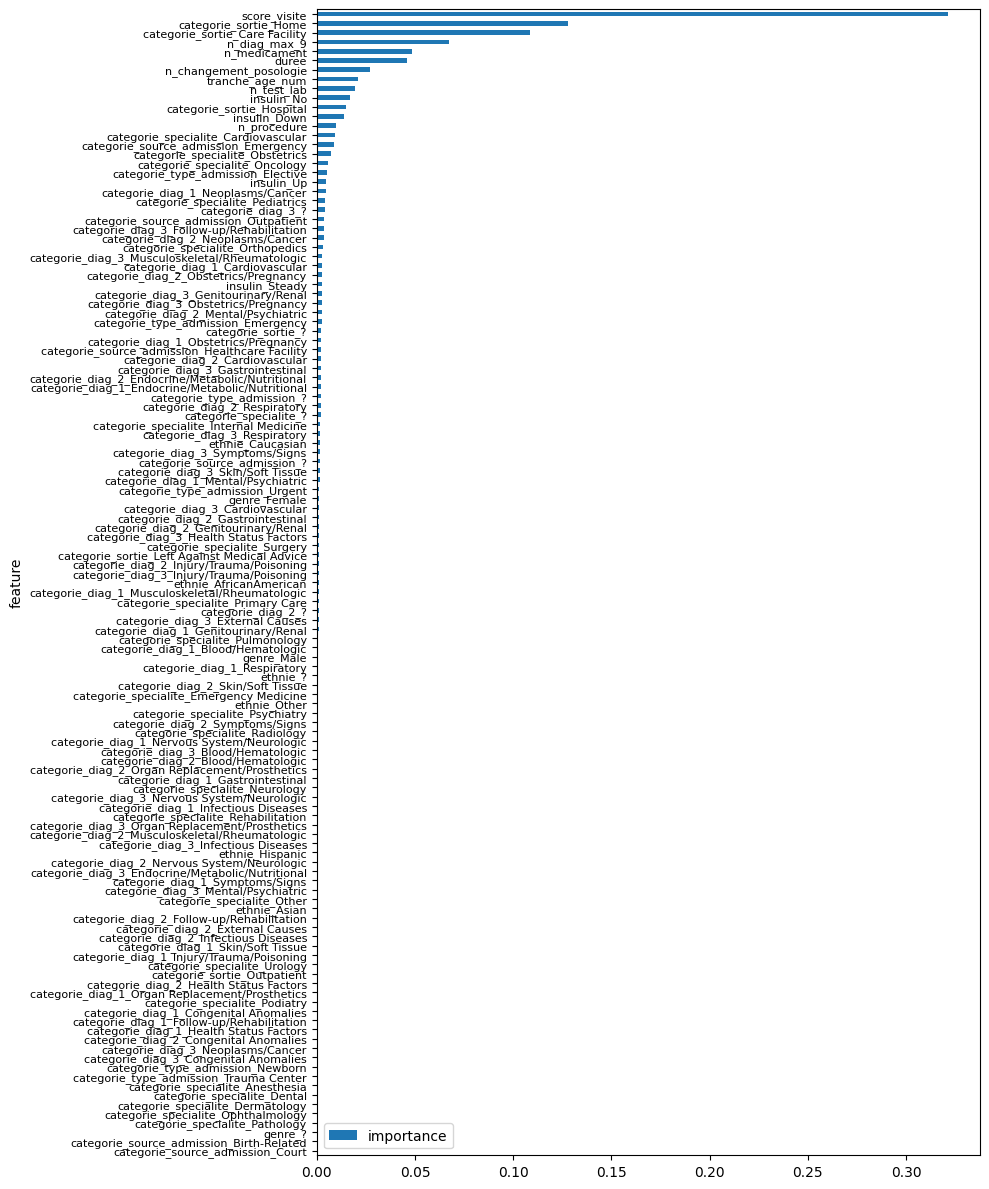


XGBClassifier:


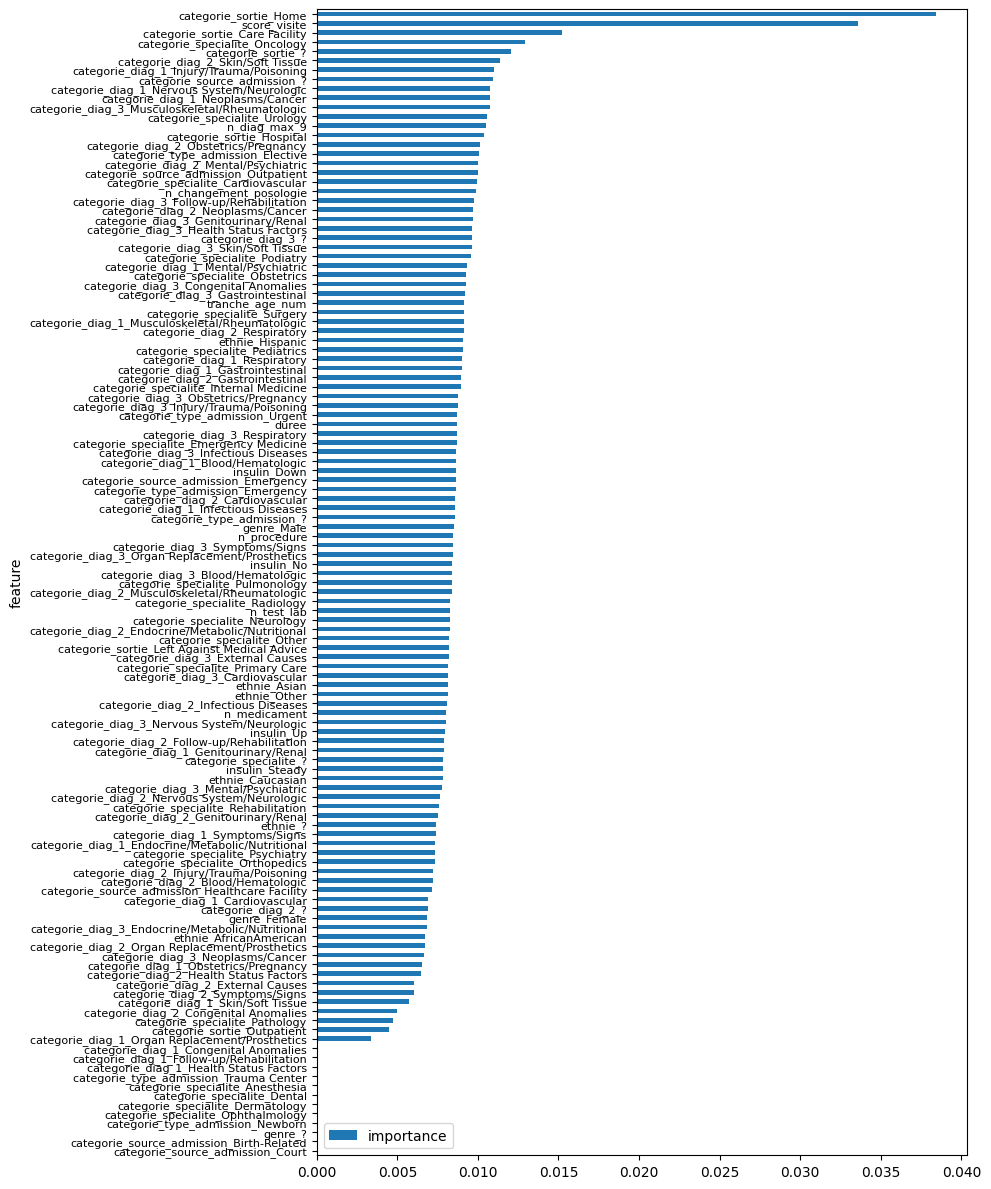

In [ ]:
feature_importance = {}

for name, result in results.items():
    best_model = result['best_model']

    if name in ['LogisticRegression', 'SGDClassifier']:
        # For linear models: use absolute coefficient values
        importances = best_model.coef_[0]
    else:
        # For tree-based models: use feature_importances_
        importances = best_model.feature_importances_

    # Create DataFrame for readability
    feature_imp_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=True, key=lambda x: np.abs(x))

    feature_importance[name] = feature_imp_df
    print(f"\n{name}:")
    fig, ax = plt.subplots(figsize=(10, 12))  # Increase height
    feature_imp_df.set_index('feature').plot.barh(ax=ax)
    ax.tick_params(axis='y', labelsize=8)  # Reduce y-label font size
    plt.tight_layout()
    plt.show()

In [ ]:
top_feature_set = set()
bottom_feature_set = set()
top = 30
i = 0
for name, feature_imp in feature_importance.items():
  imp = feature_imp['feature']
  this_top = set(imp.tail(top))
  this_bottom = set(imp.head(top))
  if i == 0:
    i = 1
    top_feature_set = this_top
    bottom_feature_set = this_bottom
  else:
    top_feature_set = top_feature_set.intersection(this_top)
    bottom_feature_set = bottom_feature_set.intersection(this_bottom)
print(top_feature_set)
print(bottom_feature_set)

{'categorie_sortie_Home', 'categorie_specialite_Obstetrics', 'categorie_diag_2_Neoplasms/Cancer', 'categorie_diag_1_Neoplasms/Cancer', 'categorie_sortie_Hospital', 'score_visite', 'categorie_sortie_Care Facility', 'categorie_specialite_Oncology'}
{'categorie_specialite_Dermatology', 'categorie_diag_1_Health Status Factors', 'categorie_diag_1_Congenital Anomalies'}


Les features les plus importantes sont celles identifiées lors de l'analyse exploratoire et lors du clustering :
- Catégorie de sortie : Home et Care Facility, Obstetrics (plus de réadmissions)
- Score de visite, corrélé avec la réadmission
- La spécialité du médecin : Oncology (plus de réadmissions)

Etonnement, des catégories de diagnostique resortent aussi, que ce soit le premier ou deuxième.

Les features les moins importantes sont toutes des catégories diverses, comme nous pouvions nous y attendre avec nos observations lors de l'exploration.

Réassayons d'entrainer ces modèles en supprimant ces features.

In [ ]:
rm_features_all = set()
i=0
for name, df_importance in feature_importance.items():
  Q4 = df_importance['importance'].quantile(0.75) # Concentration sur le top25 des features
  rm_features = set(df_importance[df_importance['importance'] <= Q4]['feature'])
  print(rm_features)
  if i == 0:
    rm_features_all = rm_features
    i = 1
  else:
    rm_features_all = rm_features_all.union(rm_features)
rm_features_all.discard("categorie_sortie_Home")
print(rm_features_all)
print(len(rm_features_all))
print("Features conservés:")
print(X.drop(rm_features_all, axis=1).columns)

{'categorie_diag_2_Skin/Soft Tissue', 'genre_?', 'categorie_diag_3_Obstetrics/Pregnancy', 'categorie_diag_1_Follow-up/Rehabilitation', 'categorie_diag_2_Endocrine/Metabolic/Nutritional', 'genre_Male', 'genre_Female', 'categorie_diag_1_Mental/Psychiatric', 'categorie_diag_2_Organ Replacement/Prosthetics', 'categorie_diag_2_Musculoskeletal/Rheumatologic', 'categorie_diag_1_Health Status Factors', 'categorie_diag_2_Nervous System/Neurologic', 'categorie_specialite_Anesthesia', 'categorie_diag_1_Gastrointestinal', 'insulin_Steady', 'categorie_diag_3_?', 'categorie_source_admission_Healthcare Facility', 'categorie_diag_2_Follow-up/Rehabilitation', 'categorie_specialite_Other', 'categorie_diag_3_Congenital Anomalies', 'categorie_specialite_Dermatology', 'categorie_sortie_?', 'categorie_specialite_Pulmonology', 'categorie_diag_3_Genitourinary/Renal', 'ethnie_Hispanic', 'categorie_source_admission_Emergency', 'categorie_sortie_Outpatient', 'categorie_sortie_Home', 'categorie_diag_3_Organ Repla

Les 9 features retenus sont :
- Le score de la visite
- Le nombre de diagnostique
- Des catégories de sortie : Care Facility, Hospital et Home (rajouté manuellement)
- Une catégorie de spécialité : Oncology
- Des catégories de diagnostiques : Neoplasms/Cancer (1 et 2), Follow-up/Rehabilitation (3)

In [ ]:
results_less_features = {}
i = 0
for name, model in models.items():
    print(name)
    df_importance = feature_importance[name]
    scores = cross_val_score(
            results[name]['best_model'],
            X_train.drop(rm_features_all, axis=1), y_train,
            cv=5,
            scoring='roc_auc',
            n_jobs=-1,
            params={'sample_weight': weights}
        )
    results_less_features[name] = scores
    print(results_less_features[name])
    print(np.mean(results_less_features[name]))

LogisticRegression
[0.65290461 0.66950803 0.65051711 0.64073671 0.62532204]
0.647797701718273
SGDClassifier
[0.64696361 0.66468833 0.64387038 0.63750765 0.62277402]
0.6431607972146498
RandomForestClassifier
[0.65225268 0.66953671 0.65426913 0.64469847 0.62662094]
0.6494755881051184
XGBClassifier
[0.64249952 0.66097905 0.65128241 0.64097657 0.62131272]
0.6434100534942442


Supprimer 93% des features simplifie énormément le modèle et produit des résultats équivalents, améliorant même le score de XGBoost de 0.56 à 0.64 !

In [ ]:
results_less_features = find_best_hyperparameters(models=models, param_distributions=param_distributions, X=X_train.drop(rm_features_all, axis=1), y=y_train)

LogisticRegression
Parametres : 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Parametres : 2
{'best_params': {'solver': 'newton-cholesky', 'max_iter': 100, 'C': np.float64(0.1)}, 'best_score': np.float64(0.6477977872132696), 'best_model': LogisticRegression(C=np.float64(0.1), random_state=42, solver='newton-cholesky')}
SGDClassifier
Parametres : 1
Parametres : 2
{'best_params': {'max_iter': 1000, 'loss': 'hinge', 'alpha': np.float64(0.0088)}, 'best_score': np.float64(0.6436614700102593), 'best_model': SGDClassifier(alpha=np.float64(0.0088), random_state=42)}
RandomForestClassifier
Parametres : 1
{'best_params': {'n_estimators': np.int64(50), 'min_samples_split': np.int64(50), 'min_samples_leaf': np.int64(25), 'max_depth': 10}, 'best_score': np.float64(0.6499010798424278), 'best_model': RandomForestClassifier(max_depth=10, min_samples_leaf=np.int64(25),
                       min_samples_split=np.int64(50),
                       n_estimators=np.int64(50), random_state=42)}
XGBClassifier
Parametres : 1
{'best_params': {'subsample': np.float64(0.6), 'n_estimators'


LogisticRegression:


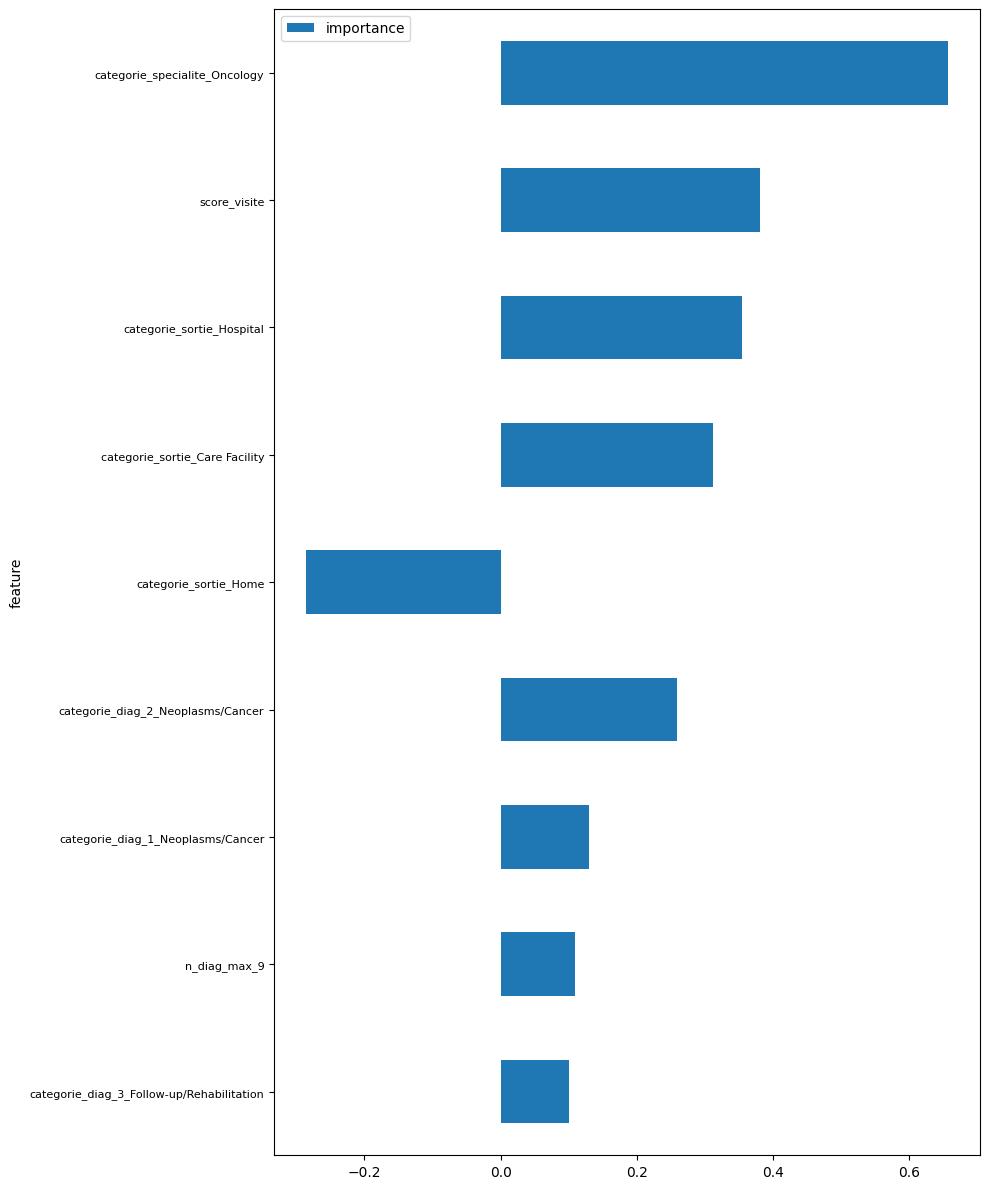


SGDClassifier:


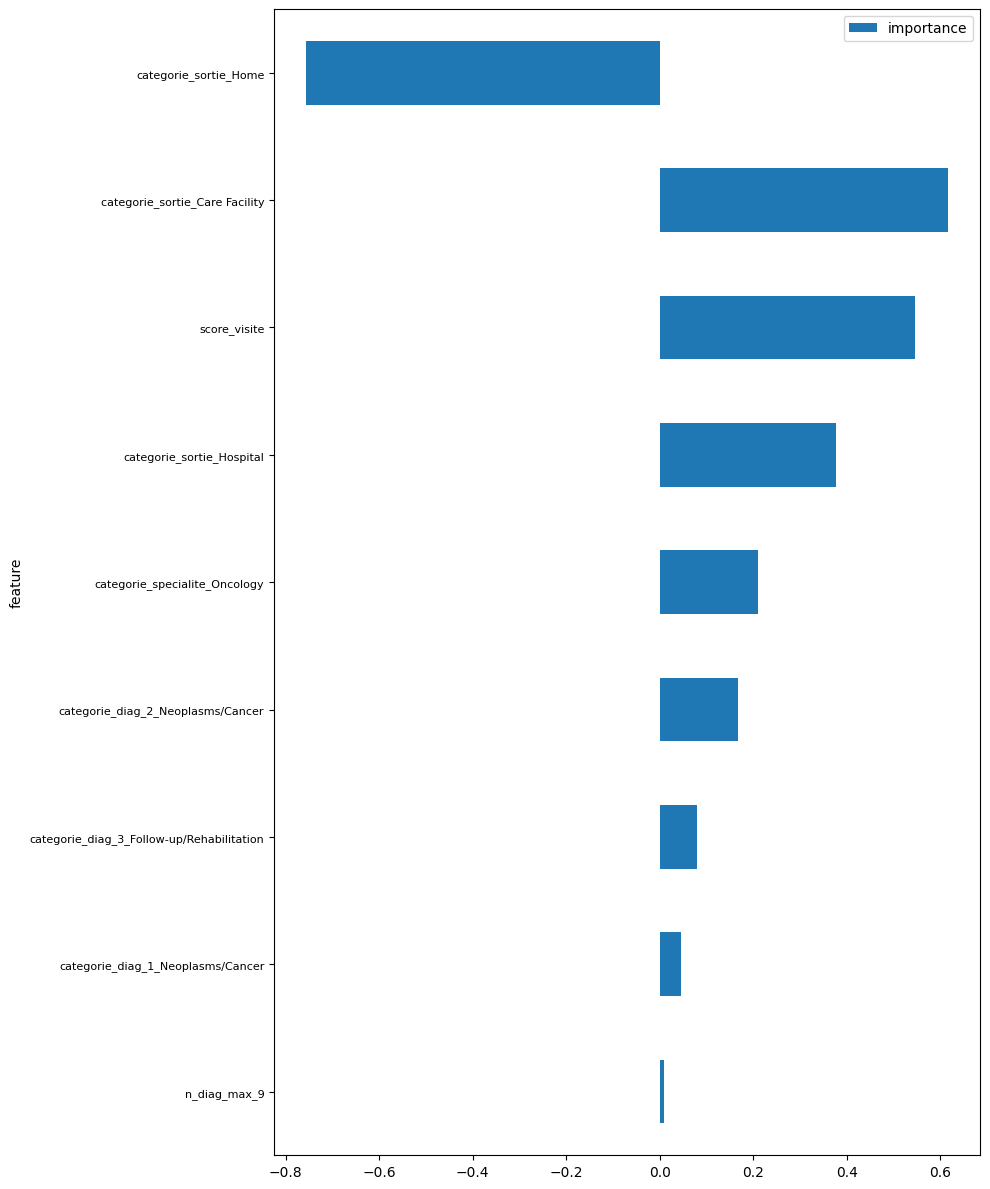


RandomForestClassifier:


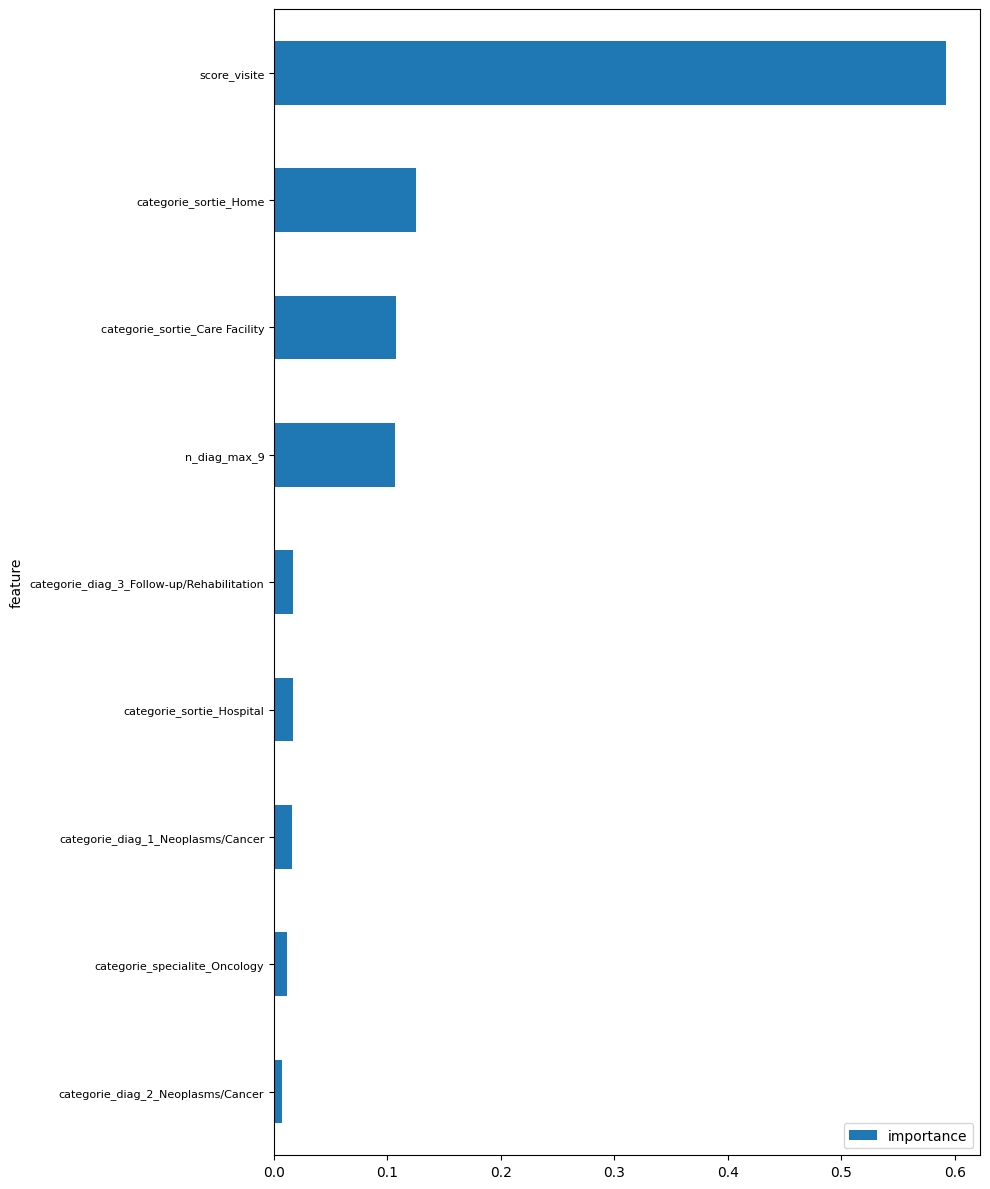


XGBClassifier:


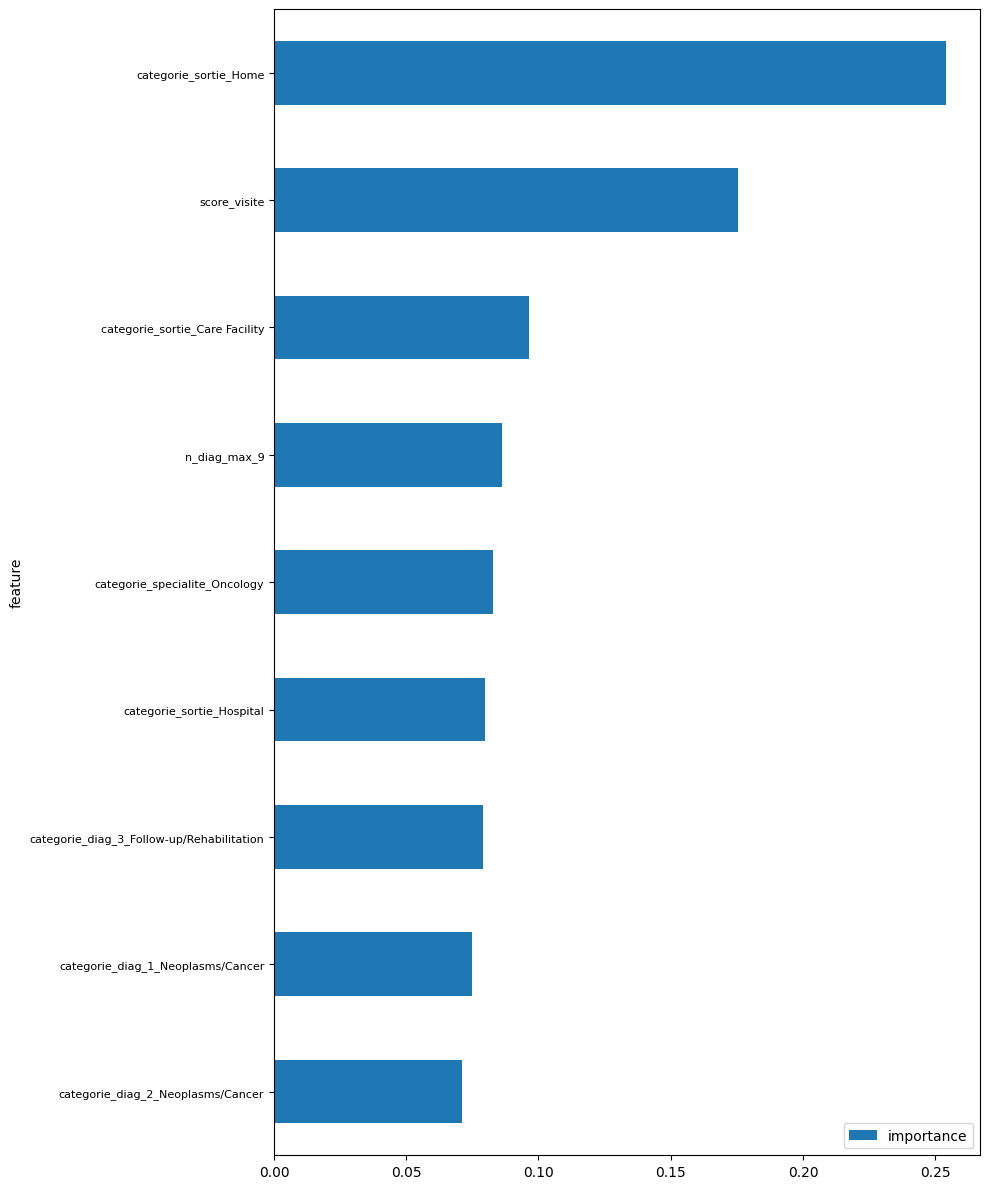

In [ ]:
feature_importance = {}

for name, result in results_less_features.items():
    best_model = result['best_model']

    if name in ['LogisticRegression', 'SGDClassifier']:
        # For linear models: use absolute coefficient values
        importances = best_model.coef_[0]
    else:
        # For tree-based models: use feature_importances_
        importances = best_model.feature_importances_

    # Create DataFrame for readability
    feature_imp_df = pd.DataFrame({
        'feature': X_train.drop(rm_features_all, axis=1).columns,
        'importance': importances
    }).sort_values('importance', ascending=True, key=lambda x: np.abs(x))

    feature_importance[name] = feature_imp_df
    print(f"\n{name}:")
    fig, ax = plt.subplots(figsize=(10, 12))  # Increase height
    feature_imp_df.set_index('feature').plot.barh(ax=ax)
    ax.tick_params(axis='y', labelsize=8)  # Reduce y-label font size
    plt.tight_layout()
    plt.show()

Un seul feature est associé à une réduction de la réadmission : la catégorie de sortie Home. Tous les autres sont positivements correlés avec la réadmission.

Les poids associés à chaque feature peuvent être très différents entre les modèles.

#### Evaluation des modèles

Examinons nos modèles de plus près.

In [ ]:
def evaluate_model(model, X, y, params={'sample_weight': weights}):
  proba = True
  try:
    y_pred_proba = cross_val_predict(model, X, y, cv=5, method="predict_proba", params=params)
    y_pred = np.where(y_pred_proba[:, 1] < 0.5, 0, 1)
  except:
    proba = False
    y_pred = cross_val_predict(model, X, y, cv=5, method="predict", params=params)
  print(confusion_matrix(y, y_pred))
  print(classification_report(y, y_pred))
  if not proba:
    return

  precision, recall, threshold = precision_recall_curve(y, y_pred_proba[:, 1])
  plt.plot(threshold, precision[:-1], "b--", label="Precision")
  plt.plot(threshold, recall[:-1], "g-", label="Recall")
  plt.legend()
  plt.show()

  fpr, tpr, threshold = roc_curve(y, y_pred_proba[:, 1])
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(10, 8))
  plt.plot(fpr, tpr, color='#2E86AB', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
  plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
  plt.xlim([-0.02, 1.02])
  plt.ylim([-0.02, 1.02])
  plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
  plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
  plt.title('ROC Curve', fontsize=14, fontweight='bold')
  plt.grid(True, alpha=0.3, linestyle='--')
  plt.legend(loc='lower right', fontsize=11)
  plt.tight_layout()
  plt.show()

  return y_pred



LogisticRegression
[[46742 23757]
 [ 4135  4991]]
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     70499
           1       0.17      0.55      0.26      9126

    accuracy                           0.65     79625
   macro avg       0.55      0.60      0.52     79625
weighted avg       0.83      0.65      0.71     79625



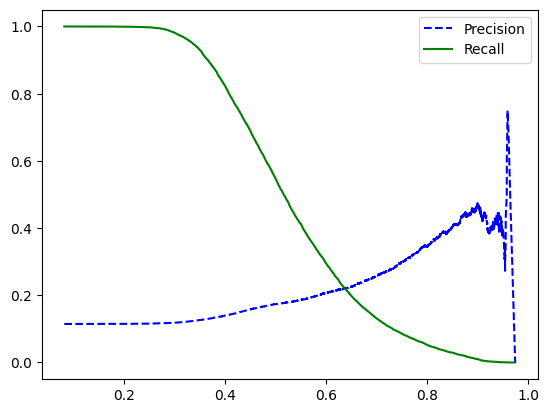

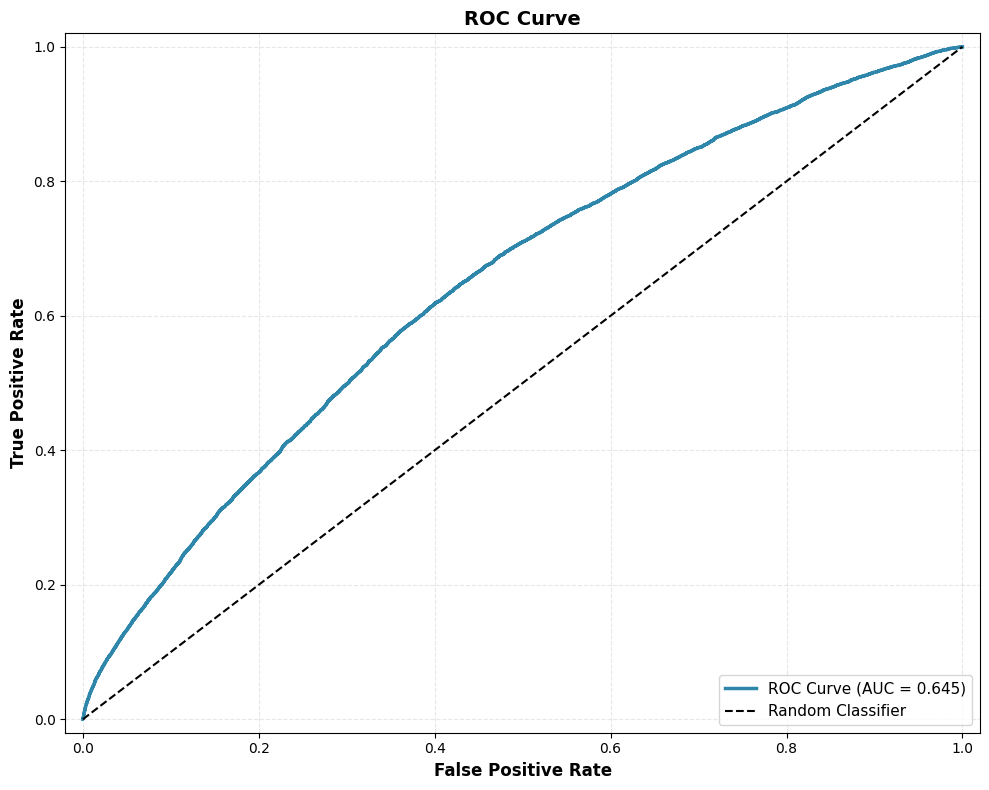

SGDClassifier
[[50854 19645]
 [ 4741  4385]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.81     70499
           1       0.18      0.48      0.26      9126

    accuracy                           0.69     79625
   macro avg       0.55      0.60      0.54     79625
weighted avg       0.83      0.69      0.74     79625

RandomForestClassifier
[[41645 28854]
 [ 4112  5014]]
              precision    recall  f1-score   support

           0       0.91      0.59      0.72     70499
           1       0.15      0.55      0.23      9126

    accuracy                           0.59     79625
   macro avg       0.53      0.57      0.47     79625
weighted avg       0.82      0.59      0.66     79625



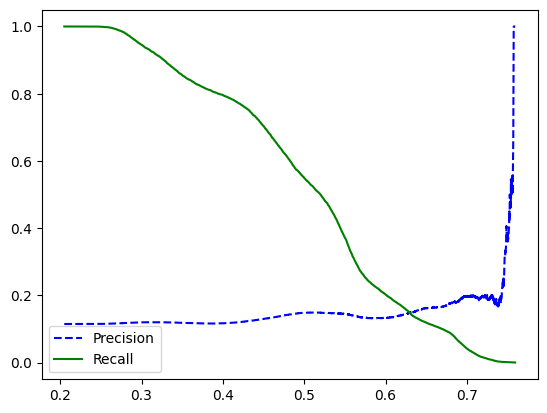

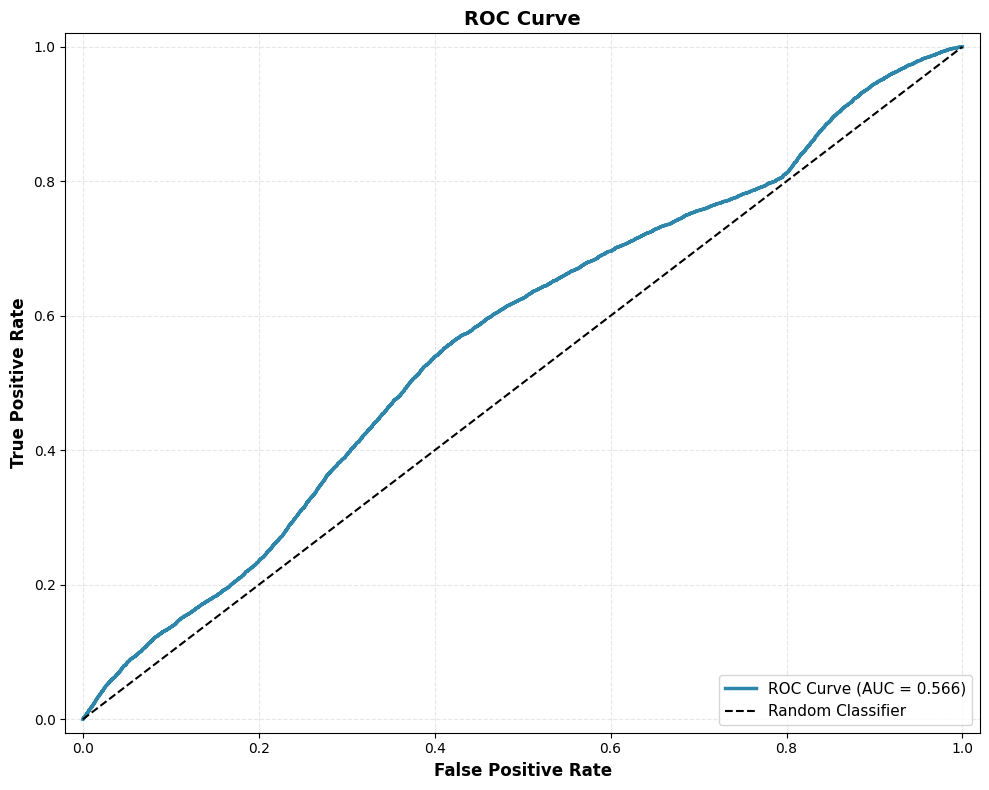

XGBClassifier
[[17315 53184]
 [ 2925  6201]]
              precision    recall  f1-score   support

           0       0.86      0.25      0.38     70499
           1       0.10      0.68      0.18      9126

    accuracy                           0.30     79625
   macro avg       0.48      0.46      0.28     79625
weighted avg       0.77      0.30      0.36     79625



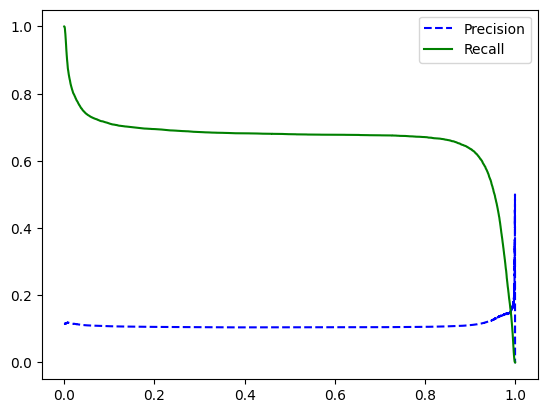

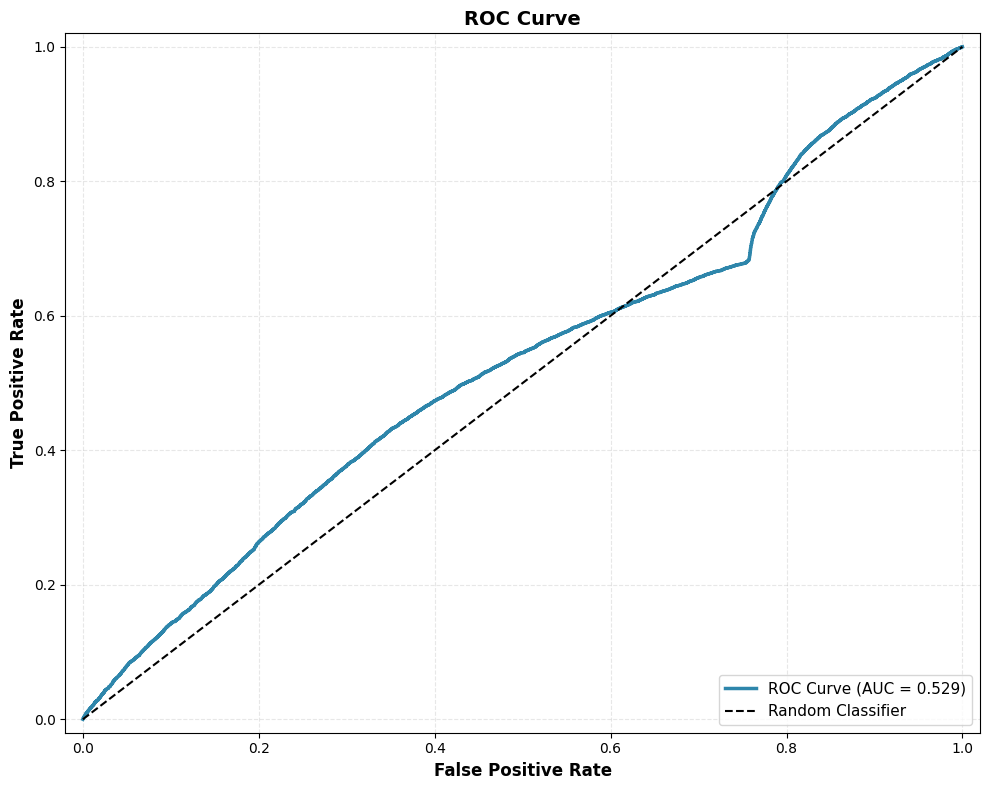

In [ ]:
for model_name, result in results.items():
  print(model_name)
  result['y_pred'] = evaluate_model(model=result['best_model'], X=X_train, y=y_train, params={'sample_weight': weights})

En utilisant l'ensemble des features, la régression logistic produit les résultats les plus intéressant (55% recall, 17% de précision). Même si XGBoost permet d'atteindre 68% de recall, c'est au prix d'une précision fortement amoindrie (10%). De plus, le modèle XGBoost n'est pas flexible (il produit des résultats équivalent pour presque tous les threshold), contrairement au modèle de régression logistique.

Examinons mantenant ces courbes sur nos modèles entrainés sur 9 features.

LogisticRegression
[[47211 23288]
 [ 4151  4975]]
              precision    recall  f1-score   support

           0       0.92      0.67      0.77     70499
           1       0.18      0.55      0.27      9126

    accuracy                           0.66     79625
   macro avg       0.55      0.61      0.52     79625
weighted avg       0.83      0.66      0.72     79625



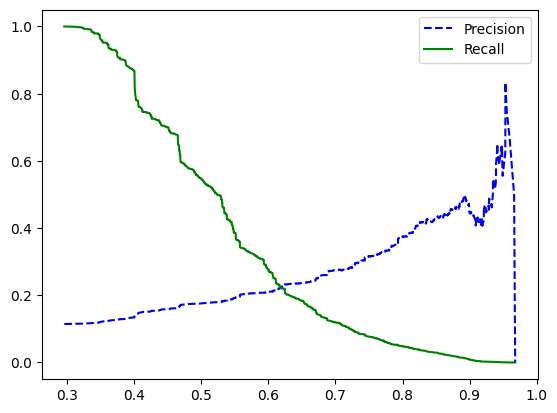

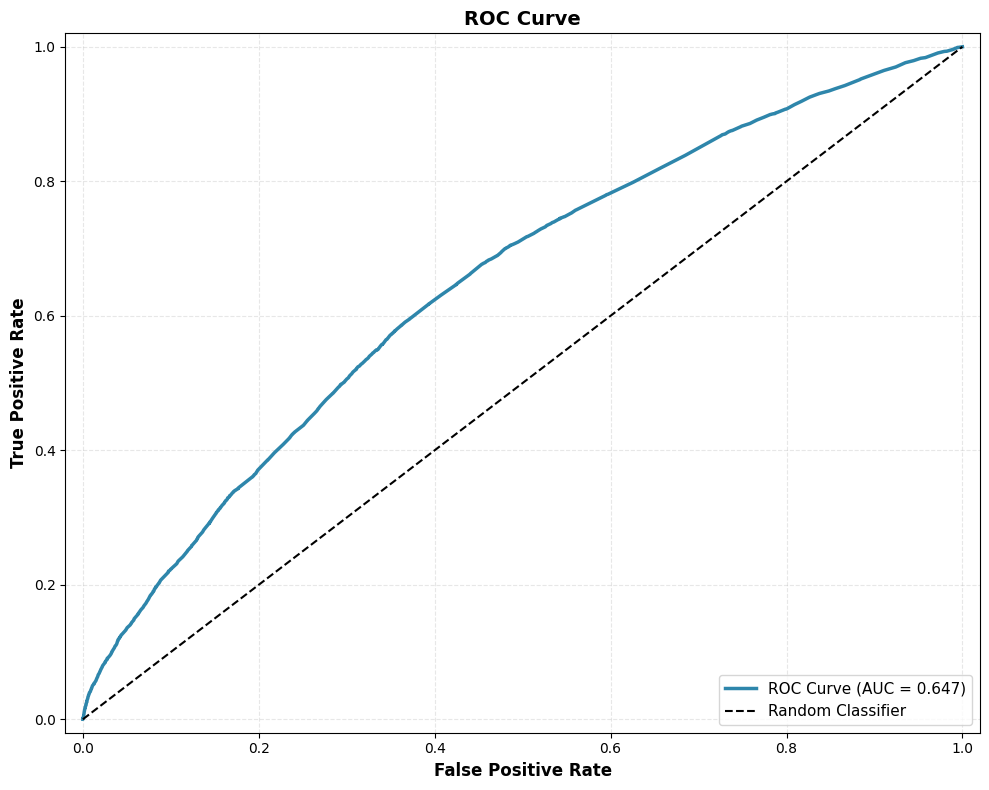

SGDClassifier
[[50571 19928]
 [ 4680  4446]]
              precision    recall  f1-score   support

           0       0.92      0.72      0.80     70499
           1       0.18      0.49      0.27      9126

    accuracy                           0.69     79625
   macro avg       0.55      0.60      0.53     79625
weighted avg       0.83      0.69      0.74     79625

RandomForestClassifier
[[45541 24958]
 [ 3842  5284]]
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     70499
           1       0.17      0.58      0.27      9126

    accuracy                           0.64     79625
   macro avg       0.55      0.61      0.51     79625
weighted avg       0.84      0.64      0.70     79625



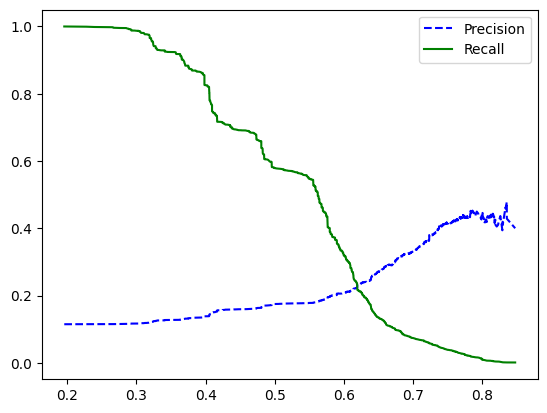

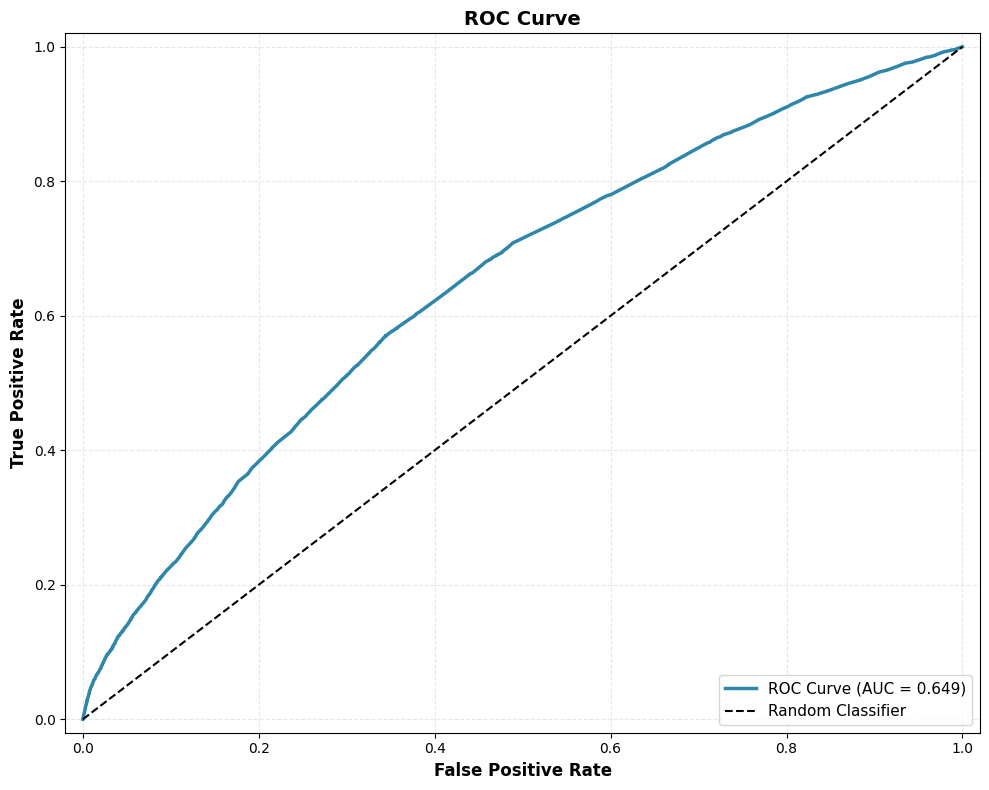

XGBClassifier
[[44714 25785]
 [ 3814  5312]]
              precision    recall  f1-score   support

           0       0.92      0.63      0.75     70499
           1       0.17      0.58      0.26      9126

    accuracy                           0.63     79625
   macro avg       0.55      0.61      0.51     79625
weighted avg       0.84      0.63      0.70     79625



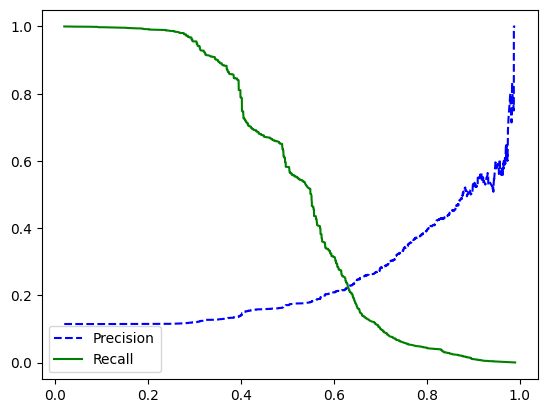

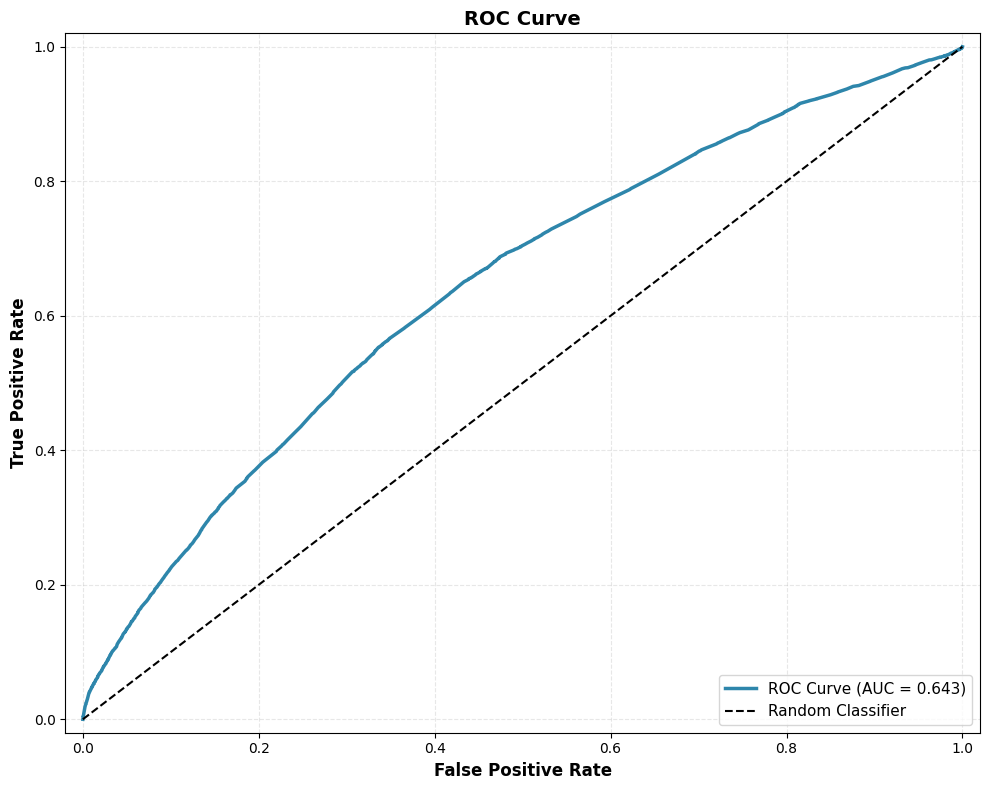

In [ ]:
for model_name, result in results_less_features.items():
  print(model_name)
  result['y_pred'] = evaluate_model(model=result['best_model'], X=X_train.drop(rm_features_all, axis=1), y=y_train, params={'sample_weight': weights})

Les performances sont équivalentes ou meilleurs pour l'ensemble des modèles, en plus d'une simplification drastique de leurs constructions et interprétation.

Les modèles se ressemblent, le RandomForestClassifier est légèrement meilleur (ROC_AUC max).

Avec ce modèle, nous pouvons capturer jusqu'à 58% des réadmissions en se trompant dans 83% des cas.

Il est possible de diminuer le threshold (0.5) pour obtenir un meilleur recall au prix d'une moins bonne précision pour la classe réadmise.

Un tpr (recall) de 58% entraine donc un fpr d'environ 28% -> un patient non réadmis a 2 chance sur 7 de tomber dans la catégorie réadmis, ce qui peut générer beaucoup d'alerte.

Nous pouvons alors ajuster le threshold (0.5 par défaut) pour réduire/augmenter le nombre d'alertes, ce qui reduira/augmentera le nombre de réadmission détectées.

### Vérification des biais algorithmiques

Vérifions les performances de l'algorithme sur des sous-groupes de variables sensibles, avec notre meilleur algorithme, le RandomForestClassifier.

In [ ]:
def calculate_metrics(group):
  report = classification_report(group['readmis'], group['y_pred'],
      zero_division=0, output_dict=True)
  return pd.Series({
        "Precision": report.get("1", {}).get("precision", 0),
        "Recall": report.get("1", {}).get("recall", 0),
        "F1-Score": report.get("1", {}).get("f1-score", 0),
        "n": group.shape[0]
    })

In [ ]:
df_train = df.iloc[train_idx].copy()
df_train['y_pred'] = results_less_features['RandomForestClassifier']['y_pred']
for col in ["tranche_age", "genre", "ethnie"]:
  print(col)
  print(df_train.groupby(col, observed=True).apply(calculate_metrics, include_groups=False))

tranche_age
             Precision    Recall  F1-Score        n
tranche_age                                        
[0-10)        0.250000  0.333333  0.285714    130.0
[10-20)       0.160000  0.484848  0.240602    537.0
[20-30)       0.293103  0.657459  0.405451   1317.0
[30-40)       0.223881  0.560748  0.320000   2982.0
[40-50)       0.204263  0.548926  0.297735   7738.0
[50-60)       0.180153  0.535688  0.269630  13676.0
[60-70)       0.176726  0.528415  0.264868  17708.0
[70-80)       0.177107  0.595152  0.272980  20306.0
[80-90)       0.154255  0.651910  0.249478  13101.0
[90-100)      0.127313  0.659004  0.213400   2130.0
genre
        Precision    Recall  F1-Score        n
genre                                         
?        0.000000  0.000000  0.000000      8.0
Female   0.172519  0.608254  0.268799  42753.0
Male     0.177757  0.544936  0.268070  36864.0
ethnie
                 Precision    Recall  F1-Score        n
ethnie                                                 
?   

- Trache d'âge
  - Le modèle est particulièrement performant pour les 20-30 ans (66% recall, 29% précision, groupe peut-être plus homogène?) et les 80+ (65% recall au détriment d'une faible précision : 14%)
  - Pour les catégories intermédiaires (30-80 ans) le modèle présente des prformances moyennes (53-59% de recall, 18-22% de précision) : mélange entre maladies chroniques plus ou moins bien régulés, complications et comorbidités.
  - Le modèle est peu performant pour des catégories d'âge faible, <20 ans (<48% de recall), pour lesquelles très peu d'hospitalisations sont observées. Les réamissions sont potentiellement plus liés à des traumatismes/accidents, moins prévisible. En tout cas, le pattern est différent de celui des adultes.
- Genre
  - Nous ignorons les hospitalisations sans genre renseigné (8 hospitalisations en tout)
  - Le modèle est plus performant pour les femmes (61% de recall) que les hommes (54% de recall). Peut-être lié au nombre plus important d'hospitalisation féminine, ou défavorisation réel de l'accès aux soins des hommes vs les femmes.
- Ethnie
  - Le modèles est plutot équilibré (meilleur sur les Caucasien car beaucoup plus de données), à l'exception des Other, correspondant à des minorités ethniques. Cela peut traduire l'accès aux soins plus difficile pour ces individus (raisons socioeconomiques, barrière de la langue).


#### Vérifications sur les données tests

Voyons si les modèles sont aussi performant sur les données test.

LogisticRegression
[[11720  5810]
 [ 1009  1179]]
              precision    recall  f1-score   support

           0       0.92      0.67      0.77     17530
           1       0.17      0.54      0.26      2188

    accuracy                           0.65     19718
   macro avg       0.54      0.60      0.52     19718
weighted avg       0.84      0.65      0.72     19718



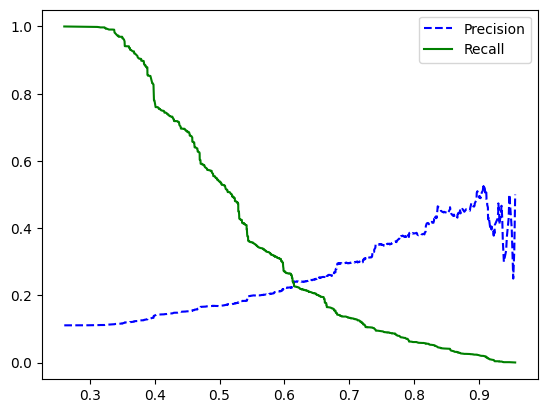

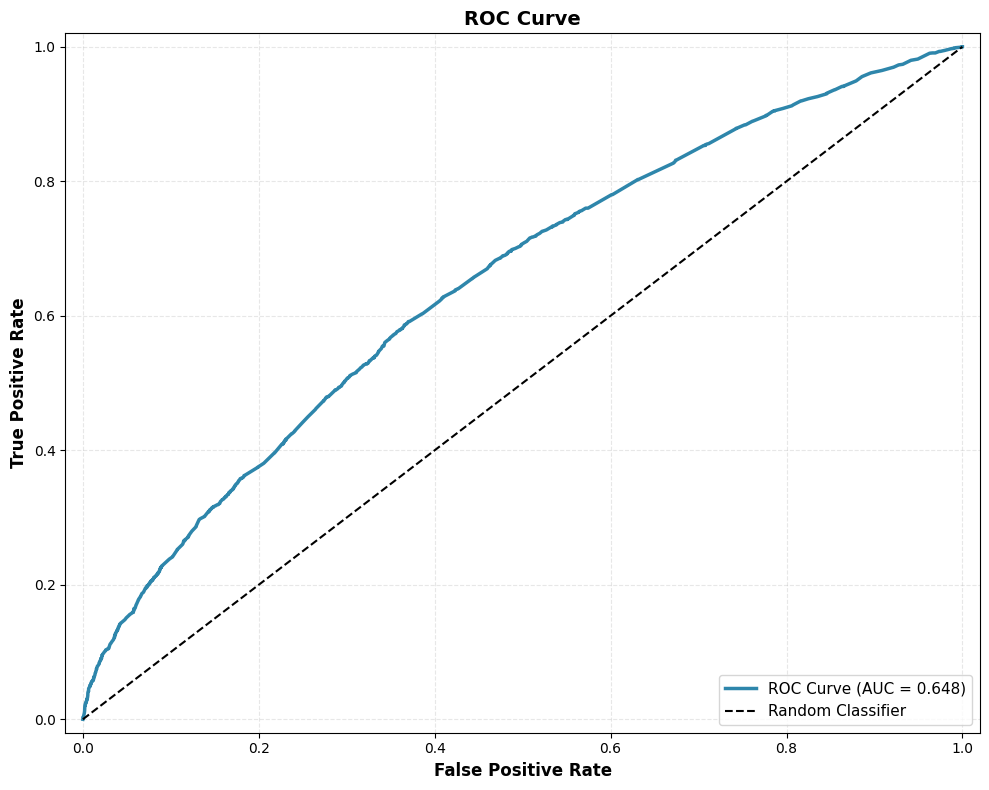

SGDClassifier
[[12650  4880]
 [ 1128  1060]]
              precision    recall  f1-score   support

           0       0.92      0.72      0.81     17530
           1       0.18      0.48      0.26      2188

    accuracy                           0.70     19718
   macro avg       0.55      0.60      0.53     19718
weighted avg       0.84      0.70      0.75     19718

RandomForestClassifier
[[11251  6279]
 [  932  1256]]
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     17530
           1       0.17      0.57      0.26      2188

    accuracy                           0.63     19718
   macro avg       0.55      0.61      0.51     19718
weighted avg       0.84      0.63      0.70     19718



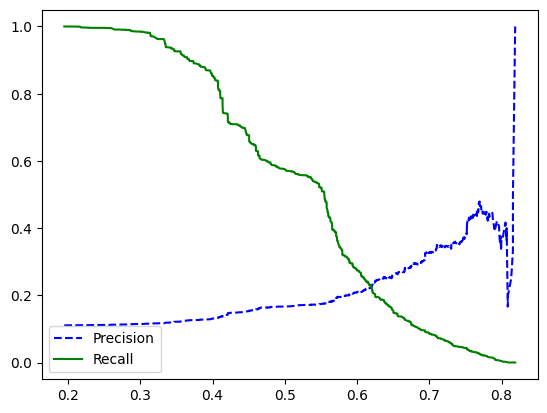

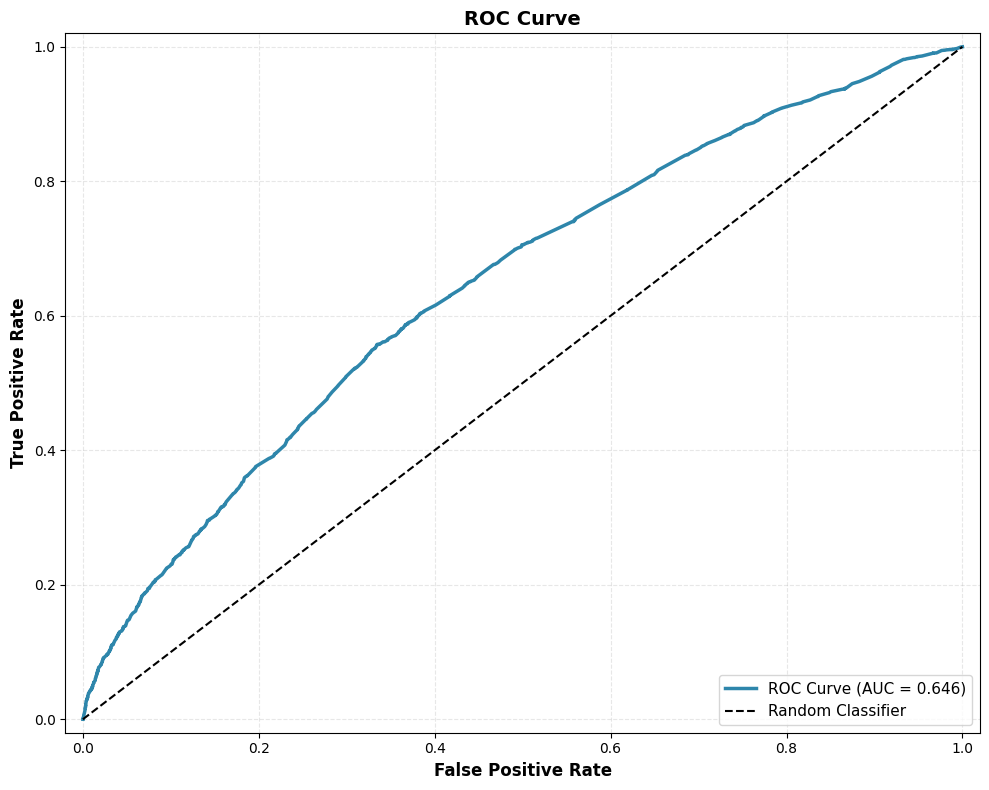

XGBClassifier
[[11564  5966]
 [ 1027  1161]]
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     17530
           1       0.16      0.53      0.25      2188

    accuracy                           0.65     19718
   macro avg       0.54      0.60      0.51     19718
weighted avg       0.83      0.65      0.71     19718



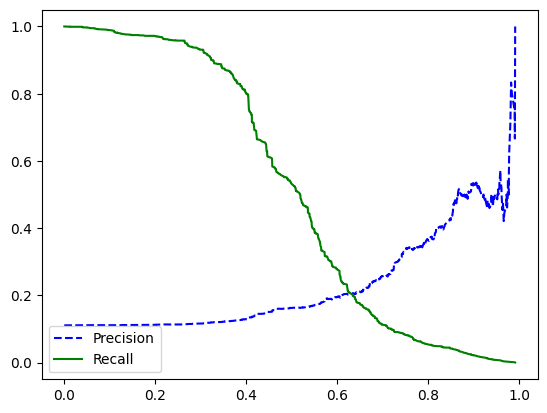

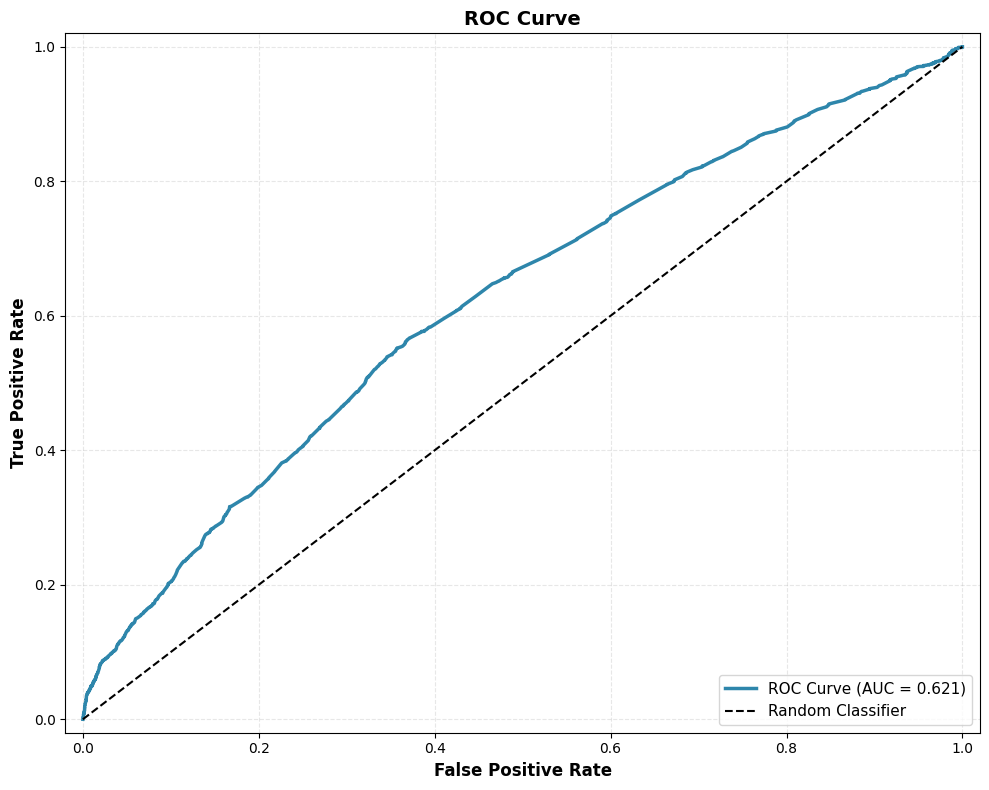

In [ ]:
for model_name, result in results_less_features.items():
  print(model_name)
  result['y_pred'] = evaluate_model(model=result['best_model'], X=X_test.drop(rm_features_all, axis=1), y=y_test, params={'sample_weight': compute_sample_weight(class_weight='balanced', y=y_test)})

Les performances sont semblables, il ne semble pas y avoir d'overfitting, les modèles généralisent bien.

In [ ]:
df_test = df.iloc[X_test.index].copy()
df_test['y_pred'] = results_less_features['RandomForestClassifier']['y_pred']
for col in ["tranche_age", "genre", "ethnie"]:
  print(col)
  print(df_test.groupby(col, observed=True).apply(calculate_metrics, include_groups=False))

tranche_age
             Precision    Recall  F1-Score       n
tranche_age                                       
[0-10)        0.000000  0.000000  0.000000    30.0
[10-20)       0.148148  0.571429  0.235294   153.0
[20-30)       0.371681  0.763636  0.500000   332.0
[30-40)       0.221311  0.524272  0.311239   782.0
[40-50)       0.170213  0.473118  0.250356  1869.0
[50-60)       0.174510  0.577922  0.268072  3384.0
[60-70)       0.174811  0.521561  0.261856  4351.0
[70-80)       0.160077  0.573402  0.250283  5025.0
[80-90)       0.152004  0.656250  0.246835  3333.0
[90-100)      0.106529  0.659574  0.183432   459.0
genre
        Precision    Recall  F1-Score        n
genre                                         
?        0.000000  0.000000  0.000000      2.0
Female   0.166211  0.603477  0.260636  10698.0
Male     0.167355  0.537755  0.255268   9018.0
ethnie
                 Precision    Recall  F1-Score        n
ethnie                                                 
?               

Les biais lié à l'age et à l'ethnie sont amplifiés sur les données tests, probablement à cause du plus faible échantillonage :
- Etonnement performant pour les 10-20 ans (57% recall) et 20-30 ans (76% de recall et 37% de précision!)
- Etonnement performant pour les Asian et Hispanic (63% recall)
- Très étonnement, le groupe ethnique Other obtient de très bon résultats (73% recall)

### Sauvegarde des données à présenter


In [ ]:
best_model = results_less_features['RandomForestClassifier']['best_model']
y_pred_proba = cross_val_predict(best_model, X_train.drop(rm_features_all, axis=1), y_train, cv=5, method="predict_proba", params={'sample_weight': weights})
y_pred = np.where(y_pred_proba[:, 1] < 0.5, 0, 1)


Performances du meilleur modèle

In [ ]:
pd.DataFrame(confusion_matrix(y_train, y_pred), index=["Vrai 0", "Vrai 1"], columns=["Predit 0", "Predit 1"]).to_csv("/content/RandomForestClassifier.confusion_matrix.csv")

In [ ]:
df_roc = pd.DataFrame(roc_curve(y_train, y_pred_proba[:, 1])).T
df_roc.columns = ["False Positive Rate", "True Positive Rate", "Threshold"]
df_roc.to_csv("/content/RandomForestClassifier.roc.csv")


In [ ]:
df_metrics = pd.DataFrame(classification_report(y_train, y_pred, output_dict=True))[["0", "1"]].T
df_metrics['roc_auc'] = auc(df_roc['False Positive Rate'], df_roc['True Positive Rate'])
df_metrics.to_csv("/content/RandomForestClassifier.metrics.csv")

Importance des features du meilleur modèle

In [ ]:
importances = best_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'feature': X_train.drop(rm_features_all, axis=1).columns,
    'importance': importances
}).sort_values('importance', ascending=False, key=lambda x: np.abs(x))
feature_imp_df.to_csv("/content/RandomForestClassifier.features_imp.csv", index=False)

#### Sauvegarde des modèles

In [ ]:
for model_name, result in results.items():
  joblib.dump(result['best_model'], f"/content/{model_name}_full.joblib")

In [ ]:
for model_name, result in results_less_features.items():
  joblib.dump(result['best_model'], f"/content/{model_name}.joblib")

# Conclusion

- Une très faible proportion de features (9) permet de construire des modèles aussi performant que ceux utilisant tous les features (115). Ces features sont : 'categorie_diag_1_Neoplasms/Cancer', 'categorie_diag_2_Neoplasms/Cancer', 'categorie_diag_3_Follow-up/Rehabilitation', 'categorie_sortie_Care Facility', 'categorie_sortie_Hospital', 'categorie_sortie_Home', 'categorie_specialite_Oncology', 'n_diag_max_9', 'score_visite'
- Seule la catégorie de sortie Home est associée à une non-réadmission.
- La plupart de ces features sont plus des conséquences que des causes:
  - Si un patient globalement en bonne santé est hospitalisé pour une raison mineure, il engendrera forcément peu de diagnostiques lors de sa visite, aura un score de visite faible puisque globalement en bonne santé et sera vraissemblablement libre de rentrer chez lui à la fin de l'hospitalisation.
  - Si un patient est hospitalisé pour des symptomes liés au cancer, il sera probablement suivi par un oncologue, aura des diagnostiques de cancers et ne sera vraissemblablement très suivi et donc pas libre de rentrer chez lui
  - Si un patient chronique, avec de lourds symptomes et complications est hospitalisé, il aura un score de visite et un nombre de diagnostiques très élevé, et sera forcément plus probablement réadmis.

Que pouvons nous faire avec nos données ?
- Les performances des modèles prédictifs sont décevantes. Le rappel de 58% avec 17% de précision signifie qu'on détecte bien les réadmissions potentielles, mais qu'on génère beaucoup de faux positifs ce qui implique une surcharge si on applique un suivi intensif à tous les patients signalés (2/7).
  - Cependant, certains groupes sont mieux prédis que les autres, notament les 20-30 ans pour lequel le modèle est bien adapté et très performant, malgré le fait que cette catégorie représente peu d'hospitalisation. Cela est probablement du à des réadmissions homogènes et bien capturé par le modèle dans ce groupe (vraissemblablement des cancers).
- Définir coûts réels : coût d'une fausse alerte vs coût d'une réadmission manquée et ajuster le threshold selon ces coûts
- La réadmission est un événement rare et multifactoriel, pouvant aussi être déterminé par des facteurs socioéconomiques, comportementaux et environementaux non observés.
- Proposer approche de prévention basé sur le clustering avec :
  - Suivi intensif pour les hospitalisations à risque (cluster 0, 6%, 26% réadmission) et les hospitalisations prédites comme donnant lieux à une réadmission par le modèle
    - Conserver ces patients quelques jours de plus en observation, de sorte à stabiliser leur état et les laisser rentrer chez eux.
    - Réaliser un suivi téléphonique hebdomadaire
    - Objectif : réduire à la moyenne de 11% de réadmissions
  - Suivi adapté pour les hospitalisations à risque (cluster 3-5, 58%, ~12% réadmission)
    - Appel téléphonique de suivi dans la semaine suivant l'hospitalisation
    - Proposer une Téléconsultation
- Le nombre de médicaments prescrits et les changements de posologie sont associés à la réadmission :
  - Eviter autant que possible de modifier un traitement existant sans indication évidente qu'il faille le changer.
  - Le diabète implique beaucoup d'auto-médication : Former les patients pour réduire les sur/sous-dosages
- Ajouter des données (métier, adresse, historique médical, dates du séjour, types de médicaments pris durant le séjour, changement de posologie sur l'ensemble des médicaments, identité du médecin responsable du séjour, médecin traitant, ...)


